In [19]:
# Standard Library
import os
import re
from pathlib import Path
from datetime import datetime

# Numerical / Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


# Geospatial
import geopandas as gpd
from shapely.geometry import Point

# Stats / Analysis
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind
from statsmodels.nonparametric.smoothers_lowess import lowess

from io import StringIO
import re




# Read Satellite dataset

In [2]:
df_coastsat = pd.read_csv('oahu0012_intersects_outliersremoved_COASTSAT.csv')
# df_coastsat['dates'] = pd.to_datetime(df_coastsat['dates'])
# df_coastsat['dates'] = df_coastsat['dates'].dt.tz_convert('Pacific/Honolulu')

# 1. Load the shapefile
shapefile_path = r"C:\Users\bgorberg\Documents\Erosion_Planet\CRC_dataset\shapefiles\NS_transects.shp"
gdf = gpd.read_file(shapefile_path)

df_coastsat['dates'] = (
    pd.to_datetime(df_coastsat['dates'])                 # make sure it's datetime                     # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_coastsat["type"] = "UNKNOWN"

df_coastsat.loc[df_coastsat["satname"].str.startswith("L"), "type"] = "LANDSAT"
df_coastsat.loc[df_coastsat["satname"].str.startswith("S"), "type"] = "SENTINEL"
#df_coastsat = df_coastsat.drop(columns=['satname'])
df_coastsat = df_coastsat.set_index('dates')




df_planet = pd.read_csv('oahu0012_intersects_outliersremoved_PLANET.csv')
df_planet['dates'] = (
    pd.to_datetime(df_planet['dates'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_planet['type'] = 'PLANET'
df_planet = df_planet.rename(columns=lambda c: re.sub(r'^(?:oahu)+_?', 'oahu', c))
df_planet = df_planet.set_index('dates')




merged_planet_coast = pd.concat([df_coastsat, df_planet])  # or drop ignore_index to keep original index
merged_planet_coast = merged_planet_coast.sort_index()

# Plot raw data at pipeline

In [ ]:
transect_col = 'oahu0012_0044'

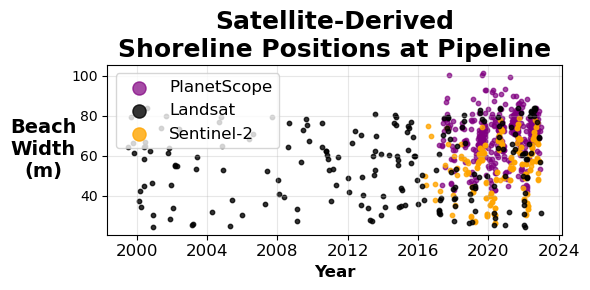

In [4]:
import matplotlib.dates as mdates

# ---- ENSURE DATETIME INDEX ----
df_planet.index = pd.to_datetime(df_planet.index)
df_coastsat.index = pd.to_datetime(df_coastsat.index)

# ---- CLIP DATA AFTER 1999 ----
start_date = "1999-01-01"
df_planet = df_planet[df_planet.index >= start_date]
df_coastsat = df_coastsat[df_coastsat.index >= start_date]


# ---- SPLIT COASTSAT INTO LANDSAT & SENTINEL ----
landsat_df = df_coastsat[df_coastsat["satname"].str.startswith("L")]
sentinel_df = df_coastsat[df_coastsat["satname"].str.startswith("S")]

# ---- CREATE FIGURE ----
plt.figure(figsize=(6,3))

# Planet (Blue)
plt.scatter(
    df_planet.index,
    df_planet[transect_col],
    color="purple",
    label="PlanetScope",
    alpha=0.7,
    s= 10,
    zorder = 0
)

# Landsat (Green)
plt.scatter(
    landsat_df.index,
    landsat_df[transect_col],
    color="black",
    label="Landsat",
    alpha=0.8,
    s= 10,
    zorder = 1
)

# Sentinel (Orange)
plt.scatter(
    sentinel_df.index,
    sentinel_df[transect_col],
    color="orange",
    label="Sentinel-2",
    alpha=0.8,
    s= 10,
    zorder = 0
)

# ---- LABELS ----
# ---- LABELS ----
plt.title("Satellite-Derived\nShoreline Positions at Pipeline",
          fontsize=18, fontweight="bold")

plt.xlabel("Year", fontsize=12, fontweight="bold")
plt.ylabel("Beach Width (m)", fontsize=14, fontweight="bold")


ax = plt.gca()

# ticks every 5 years
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# make ticks larger and bold
plt.xticks(fontsize=12)
plt.grid(alpha=0.3)
plt.legend(fontsize = 12, loc ='upper left', markerscale = 3)
plt.grid(alpha=0.3)
plt.ylabel("Beach\nWidth\n(m)", rotation=0,labelpad=20, va = 'center')
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", "satellite_sources" +transect_col+".png"), dpi=300, bbox_inches="tight")
plt.show()


# Calculate Mean Bias

In [50]:

# ----------------------------------------------------
# Ensure datetime index
# ----------------------------------------------------

# --- Recompute overall means (2016-12-31 onward) ---
start_date = pd.Timestamp("2016-12-31").tz_localize(merged_planet_coast.index.tz)
df_filtered = merged_planet_coast.loc[start_date:]
df_filtered.index = pd.to_datetime(df_filtered.index)
df_filtered = df_filtered.sort_index()

# ----------------------------------------------------
# Identify transect columns
# ----------------------------------------------------
transect_cols = [col for col in df_filtered.columns if col.startswith("oahu")]

# ----------------------------------------------------
# Split by satellite type
# ----------------------------------------------------
planet_df = df_filtered[df_filtered["type"] == "PLANET"][transect_cols]
landsat_df = df_filtered[df_filtered["type"] == "LANDSAT"][transect_cols]
sentinel_df = df_filtered[df_filtered["type"] == "SENTINEL"][transect_cols]

# ----------------------------------------------------
# Resample to monthly means
# ----------------------------------------------------
planet_monthly = planet_df.resample("M").mean()
landsat_monthly = landsat_df.resample("M").mean()
sentinel_monthly = sentinel_df.resample("M").mean()

# ----------------------------------------------------
# Compute mean of monthly values (equal monthly weighting)
# ----------------------------------------------------
planet_mean = planet_monthly.mean()
landsat_mean = landsat_monthly.mean()
sentinel_mean = sentinel_monthly.mean()

# ----------------------------------------------------
# Build bias dataframe
# ----------------------------------------------------
bias_monthly_df = pd.DataFrame({
    "transect": transect_cols,
    "planet_monthly_mean": planet_mean.values,
    "landsat_monthly_mean": landsat_mean.values,
    "sentinel_monthly_mean": sentinel_mean.values,
})

bias_monthly_df["planet_minus_landsat"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["landsat_monthly_mean"]
)

bias_monthly_df["planet_minus_sentinel"] = (
    bias_monthly_df["planet_monthly_mean"]
    - bias_monthly_df["sentinel_monthly_mean"]
)


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\899495894.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  planet_monthly = planet_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\899495894.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  landsat_monthly = landsat_df.resample("M").mean()
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\899495894.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sentinel_monthly = sentinel_df.resample("M").mean()


# Plot shows bias is transect dependent and not global bias

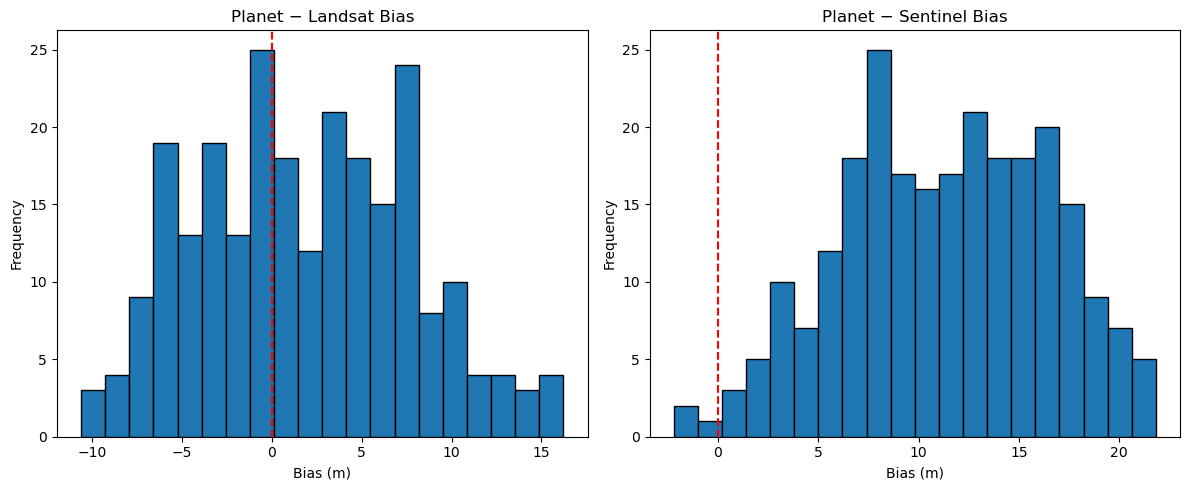

In [6]:
# Extract columns
bias_ls = bias_monthly_df["planet_minus_landsat"]
bias_sn = bias_monthly_df["planet_minus_sentinel"]

# Create figure
plt.figure(figsize=(12,5))

# Planet - Landsat
plt.subplot(1,2,1)
plt.hist(bias_ls.dropna(), bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Planet − Landsat Bias")
plt.xlabel("Bias (m)")
plt.ylabel("Frequency")

# Planet - Sentinel
plt.subplot(1,2,2)
plt.hist(bias_sn.dropna(), bins=20, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Planet − Sentinel Bias")
plt.xlabel("Bias (m)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Apply BIAS Correction

In [7]:
# --- Copy original dataset ---
merged_corrected = merged_planet_coast.copy()

# --- Identify transect columns ---
transect_cols = [col for col in merged_corrected.columns if col.startswith("oahu")]


satellite_means = (
    df_filtered
    .groupby("type")[transect_cols]
    .mean()
    .mean(axis=1)
)

# --------------------------------------------
# Copy dataset to preserve original
# --------------------------------------------
merged_corrected = merged_planet_coast.copy()

# Identify transect columns
transect_cols = bias_monthly_df["transect"].values

# --------------------------------------------
# Apply transect-by-transect correction
# --------------------------------------------
for _, row in bias_monthly_df.iterrows():
    
    transect = row["transect"]
    
    bias_ls = row["planet_minus_landsat"]
    bias_sn = row["planet_minus_sentinel"]
    
    # Correct LANDSAT
    merged_corrected.loc[
        merged_corrected["type"] == "LANDSAT",
        transect
    ] += bias_ls
    
    # Correct SENTINEL
    merged_corrected.loc[
        merged_corrected["type"] == "SENTINEL",
        transect
    ] += bias_sn

print("Per-transect monthly bias correction applied.")

Per-transect monthly bias correction applied.


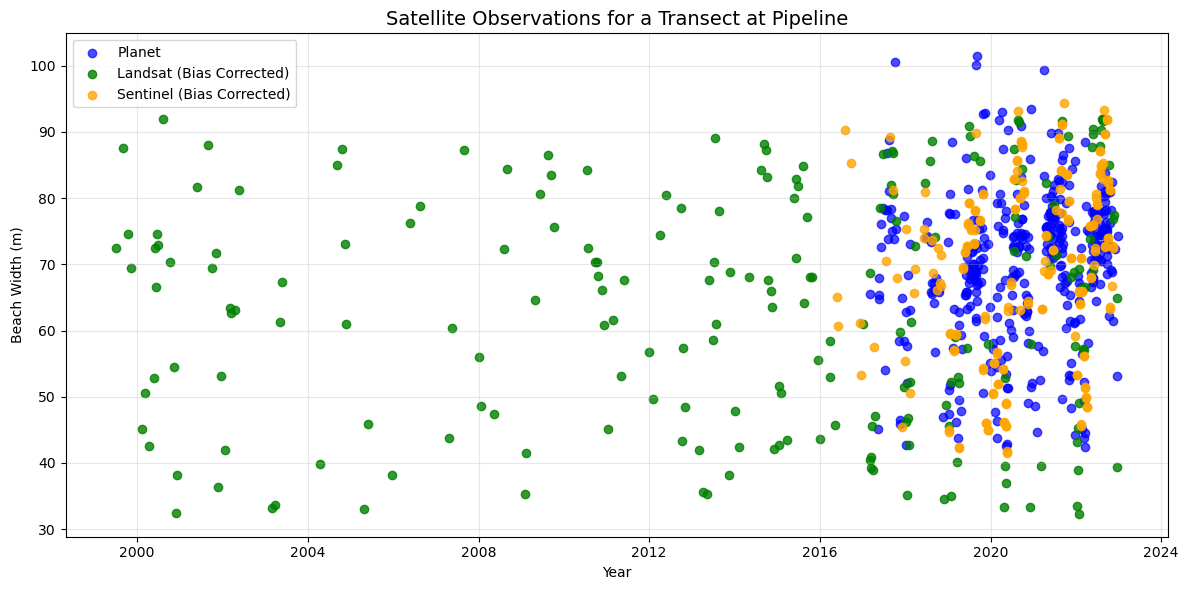

In [8]:

# ---- ENSURE DATETIME INDEX ----
merged_corrected.index = pd.to_datetime(merged_corrected.index)
merged_corrected = merged_corrected.sort_index()

# ---- DEFINE DATE RANGE (match timezone automatically) ----
tz = merged_corrected.index.tz
start_date = pd.Timestamp("1999-01-01").tz_localize(tz)
end_date = pd.Timestamp("2024-12-31").tz_localize(tz)

# ---- FILTER DATE RANGE ----
df_plot = merged_corrected.loc[start_date:end_date]

# ---- SPLIT BY TYPE ----
planet_df = df_plot[df_plot["type"] == "PLANET"]
landsat_df = df_plot[df_plot["type"] == "LANDSAT"]
sentinel_df = df_plot[df_plot["type"] == "SENTINEL"]

# ---- CREATE FIGURE ----
plt.figure(figsize=(12,6))

plt.scatter(planet_df.index, planet_df[transect_col],
            color="blue", label="Planet", alpha=0.7)

plt.scatter(landsat_df.index, landsat_df[transect_col],
            color="green", label="Landsat (Bias Corrected)", alpha=0.8)

plt.scatter(sentinel_df.index, sentinel_df[transect_col],
            color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)

plt.title("Satellite Observations for a Transect at Pipeline", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Beach Width (m)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Read updated dataset that Anna sent from 2023-2024

In [9]:
df_updated = pd.read_csv(os.path.join("NS-oahu0012-update", "oahu0012_intersects_outliersremoved_clean.csv"))
df_updated['timestamp'] = (
    pd.to_datetime(df_updated['timestamp'])                 # make sure it's datetime
    .dt.tz_localize('UTC')                      # tell pandas this is UTC time
    .dt.tz_convert('Pacific/Honolulu')          # convert to Hawaii Standard Time
)
df_updated = df_updated.set_index("timestamp")

In [10]:
# Ensure both are sorted
merged_planet_coast = merged_corrected.copy().sort_index()
df_updated = df_updated.sort_index()

# Get last timestamp from original dataframe
last_date = merged_planet_coast.index.max()

# Keep only newer rows from df_updated
df_updated_new = df_updated.loc[df_updated.index > last_date]

# Concatenate
merged_final = pd.concat([merged_planet_coast, df_updated_new]).sort_index()

### Resample to monthly medians (NO rolling

In [11]:
# monthly -> add merge key
def generate_transect_list(start_transect, end_transect):
    """Generate a list of transect IDs from start to end, inclusive."""
    return [f"oahu0012_{i:04d}" for i in range(start_transect, end_transect + 1)]
last_transect_number = 246
monthly_planet_coast  =  merged_final.resample('M').median(numeric_only=True)
monthly_median_planet_coast = monthly_planet_coast[monthly_planet_coast.index >= "1999-07-01"]

monthly_medians_stats = {'baseline_std': [], 'baseline_average': [], 'transect': []}
lst = list(range(1, last_transect_number +1))
for i in lst:
    transect =  generate_transect_list(start_transect = i, end_transect = i)[0]
    baseline_avg = monthly_planet_coast[transect].mean()
    baseline_std = monthly_planet_coast[transect].std()
    monthly_medians_stats['baseline_average'].append(baseline_avg)
    monthly_medians_stats['baseline_std'].append(baseline_std)
    monthly_medians_stats['transect'].append(transect)

monthly_medians_stats_raw  = pd.DataFrame(monthly_medians_stats)

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\1014326759.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_planet_coast  =  merged_final.resample('M').median(numeric_only=True)


#### rolling transect

# READ MEI DATA for 

In [60]:
cwd = os.getcwd()
index_path = os.path.join(cwd, "Raw_Climate_Index")
MEI_file = "meiv2.data"
file_path = os.path.join(index_path, MEI_file)

# Read all lines
with open(file_path, "r") as f:
    lines = f.readlines()

# Keep only valid data lines (start with 4-digit year and contain at least 13 numeric values)
pattern = re.compile(r'^\s*\d{4}\s+')
data_lines = [line.strip() for line in lines if pattern.match(line) and len(line.split()) >= 13]

# Join the lines into a single string
data_str = "\n".join(data_lines)

# Read into DataFrame
df = pd.read_csv(StringIO(data_str), sep=r"\s+", header=None)

# Assign column names (Year + 12 months)
df.columns = ["Year", "Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Convert data to numeric safely
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert to long format with datetime index
df_long = df.melt(id_vars="Year", var_name="Month", value_name="MEI")
df_long["Date"] = pd.to_datetime(df_long["Year"].astype(str) + df_long["Month"], format="%Y%b")
df_long = df_long[["Date", "MEI"]].sort_values("Date").reset_index(drop=True)

df_long['ENSO'] = np.nan
for i in range(len(df_long.MEI)):
    if df_long.MEI[i] >= 0.5:
        df_long.ENSO[i] = 'EL NINO'
    elif df_long.MEI[i] <= -0.5:
        df_long.ENSO[i] = 'LA NINA'
    else:
        df_long.ENSO[i] = 'NUETRAL'
    
MEI_dataset = df_long.copy()

# copy to avoid modifying original
mei = MEI_dataset.copy()

# ensure datetime
mei['Date'] = pd.to_datetime(mei['Date'])

# remove invalid values (-999)
mei = mei[mei['MEI'] != -999].copy()

# define ENSO winter year (Nov–Mar)
mei['enso_year'] = np.where(
    mei['Date'].dt.month >= 11,
    mei['Date'].dt.year + 1,
    mei['Date'].dt.year
)

# keep only Nov–Mar
mei_winter = mei[
    mei['Date'].dt.month.isin([12, 1, 2])
].copy()

# copy and clean
mei = MEI_dataset.copy()
mei['Date'] = pd.to_datetime(mei['Date'])

# remove missing placeholder values
mei = mei[mei['MEI'] != -999].copy()

# keep only DJF months
mei_djf = mei[mei['Date'].dt.month.isin([12, 1, 2])].copy()

# define season year:
# Dec 1980, Jan 1981, Feb 1981 -> "1980-1981"
mei_djf['season_year_start'] = np.where(
    mei_djf['Date'].dt.month == 12,
    mei_djf['Date'].dt.year,
    mei_djf['Date'].dt.year - 1
)

mei_djf['season_year'] = (
    mei_djf['season_year_start'].astype(str) + '-' +
    (mei_djf['season_year_start'] + 1).astype(str)
)

# calculate average DJF MEI
mei_summary = (
    mei_djf.groupby('season_year', as_index=False)['MEI']
    .mean()
    .rename(columns={'MEI': 'avg_MEI_DJF'})
)

# classify ENSO label from average DJF MEI
def classify_enso(x):
    if pd.isna(x):
        return np.nan
    elif x >= 0.5:
        return 'POSITIVE'
    elif x <= -0.5:
        return 'NEGATIVE'
    else:
        return 'NEUTRAL'

mei_summary['ENSO_label'] = mei_summary['avg_MEI_DJF'].apply(classify_enso)

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2837106265.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_long.ENSO[i] = 'NUETRAL'
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2837106265.py:40: SettingWithCopyWarning: 


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2122727260.py:73: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2122727260.py:62: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(


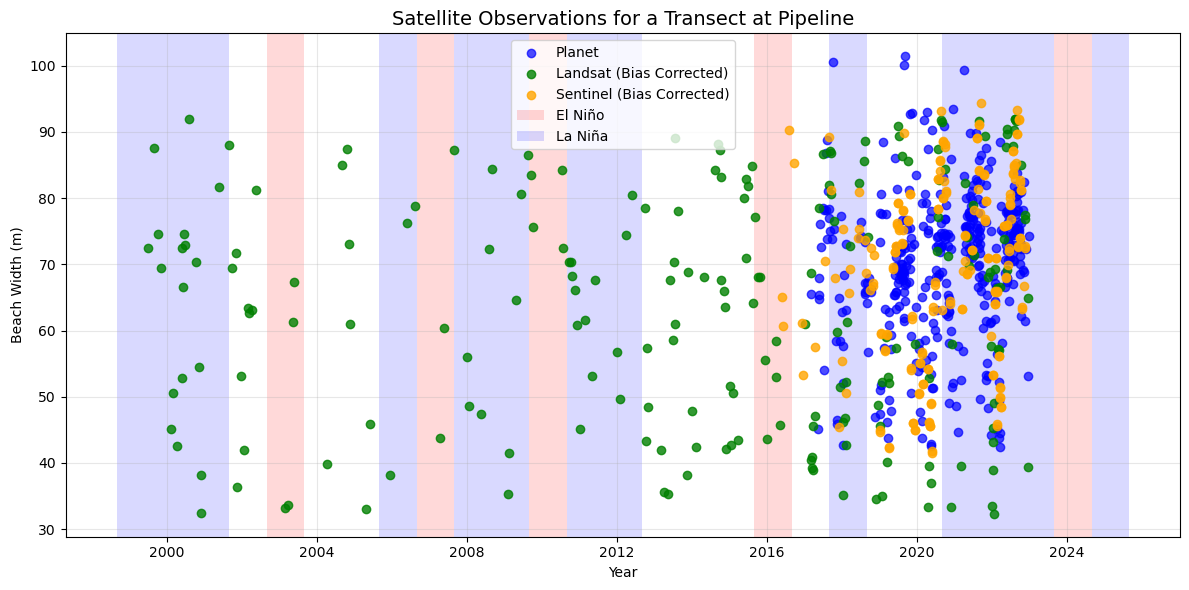

In [64]:
# ---- ENSURE DATETIME INDEX ----
merged_corrected.index = pd.to_datetime(merged_corrected.index)
merged_corrected = merged_corrected.sort_index()

# ---- DEFINE DATE RANGE (match timezone automatically) ----
tz = merged_corrected.index.tz

if tz is not None:
    start_date = pd.Timestamp("1999-01-01").tz_localize(tz)
    end_date = pd.Timestamp("2024-12-31").tz_localize(tz)
else:
    start_date = pd.Timestamp("1999-01-01")
    end_date = pd.Timestamp("2024-12-31")

# ---- FILTER DATE RANGE ----
df_plot = merged_corrected.loc[start_date:end_date]

# ---- SPLIT BY TYPE ----
planet_df = df_plot[df_plot["type"] == "PLANET"]
landsat_df = df_plot[df_plot["type"] == "LANDSAT"]
sentinel_df = df_plot[df_plot["type"] == "SENTINEL"]

# ---- CREATE FIGURE ----
fig, ax = plt.subplots(figsize=(12, 6))

# ==========================================================
# ADD ENSO BACKGROUND SHADING
# Assumes mei_summary has columns:
# season_year, avg_MEI_DJF, ENSO_label
# Example season_year: "1999-2000"
# Season runs Sept 1 of first year through Aug 31 of second year
# ==========================================================

for _, row in mei_summary.iterrows():

    season = row["season_year"]
    label = row["ENSO_label"]

    # Skip neutral years
    if label == "NEUTRAL":
        continue

    # Extract start and end year from string like "1999-2000"
    start_year, end_year = season.split("-")
    start_year = int(start_year)
    end_year = int(end_year)

    # Define ENSO season window
    enso_start = pd.Timestamp(f"{start_year}-09-01")
    enso_end = pd.Timestamp(f"{end_year}-08-31")

    # Match timezone if needed
    if tz is not None:
        enso_start = enso_start.tz_localize(tz)
        enso_end = enso_end.tz_localize(tz)

    # Only shade seasons that overlap your plotting period
    if enso_end < start_date or enso_start > end_date:
        continue

    if label == "POSITIVE":   # El Niño
        ax.axvspan(
            enso_start,
            enso_end,
            color="red",
            alpha=0.15,
            linewidth=0,
            edgecolor="none",
            zorder=0
        )
    
    elif label == "NEGATIVE": # La Niña
        ax.axvspan(
            enso_start,
            enso_end,
            color="blue",
            alpha=0.15,
            linewidth=0,
            edgecolor="none",
            zorder=0
        )
# ---- SATELLITE SCATTER PLOTS ----
ax.scatter(
    planet_df.index,
    planet_df[transect_col],
    color="blue",
    label="Planet",
    alpha=0.7,
    zorder=3
)

ax.scatter(
    landsat_df.index,
    landsat_df[transect_col],
    color="green",
    label="Landsat (Bias Corrected)",
    alpha=0.8,
    zorder=3
)

ax.scatter(
    sentinel_df.index,
    sentinel_df[transect_col],
    color="orange",
    label="Sentinel (Bias Corrected)",
    alpha=0.8,
    zorder=3
)

# ---- OPTIONAL: ADD CUSTOM ENSO LEGEND PATCHES ----
from matplotlib.patches import Patch

enso_legend = [
    Patch(facecolor="red", alpha=0.15, label="El Niño"),
    Patch(facecolor="blue", alpha=0.15, label="La Niña")
]

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + enso_legend, labels=labels + ["El Niño", "La Niña"])

# ---- LABELS / FORMATTING ----
ax.set_title("Satellite Observations for a Transect at Pipeline", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Beach Width (m)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

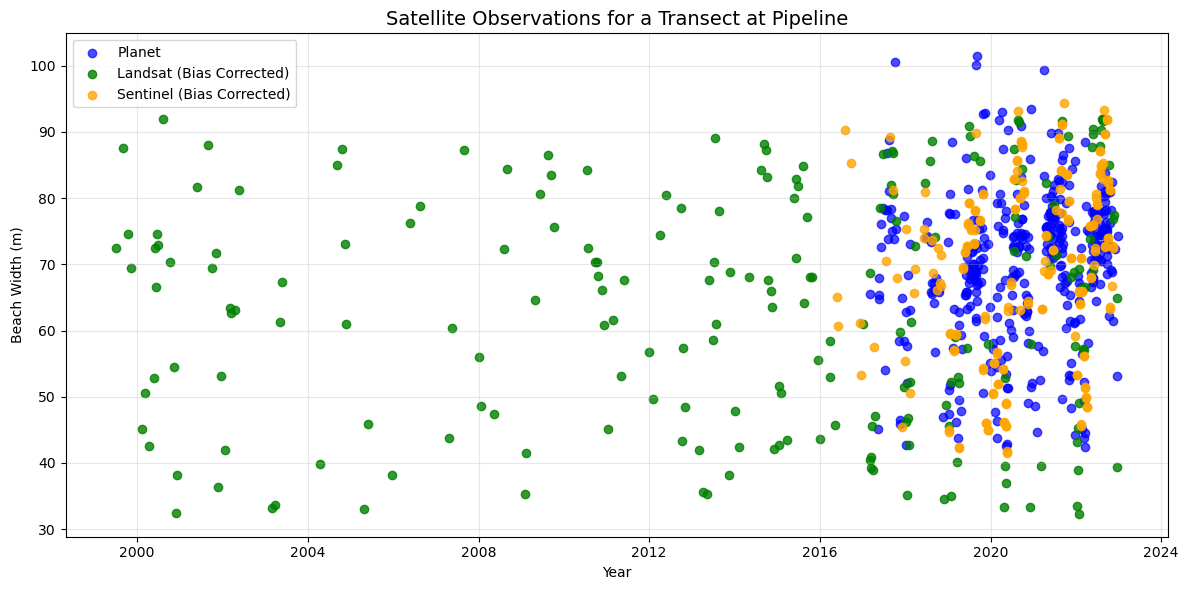

In [57]:

# ---- ENSURE DATETIME INDEX ----
merged_corrected.index = pd.to_datetime(merged_corrected.index)
merged_corrected = merged_corrected.sort_index()

# ---- DEFINE DATE RANGE (match timezone automatically) ----
tz = merged_corrected.index.tz
start_date = pd.Timestamp("1999-01-01").tz_localize(tz)
end_date = pd.Timestamp("2024-12-31").tz_localize(tz)

# ---- FILTER DATE RANGE ----
df_plot = merged_corrected.loc[start_date:end_date]

# ---- SPLIT BY TYPE ----
planet_df = df_plot[df_plot["type"] == "PLANET"]
landsat_df = df_plot[df_plot["type"] == "LANDSAT"]
sentinel_df = df_plot[df_plot["type"] == "SENTINEL"]

# ---- CREATE FIGURE ----
plt.figure(figsize=(12,6))

plt.scatter(planet_df.index, planet_df[transect_col],
            color="blue", label="Planet", alpha=0.7)

plt.scatter(landsat_df.index, landsat_df[transect_col],
            color="green", label="Landsat (Bias Corrected)", alpha=0.8)

plt.scatter(sentinel_df.index, sentinel_df[transect_col],
            color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)

plt.title("Satellite Observations for a Transect at Pipeline", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Beach Width (m)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate a figure from a selected transect

In [88]:
# all_transects = merged_final.columns[:-2].to_list()

# for transect in all_transects:
#     full_raw = merged_final[merged_final.index >= "1999-07-01"][[transect]].copy()
#     dataset = monthly_median_planet_coast
#     monthly_medians_stats = monthly_medians_stats_raw.copy()


#     df_transect = dataset[[transect]].copy() #monthly and rolling
    
#     # ------------------------------------------------------------
#     # CREATE 4 SUBPLOTS WITH SHARED X-AXIS
#     # ------------------------------------------------------------
#     fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
#     (ax1, ax2, ax3, ax4, ax5) = axes
    
#     #-----------------------------------------------------------
#     # RAW PLANET COAST SAT DATA FROM CHIP
#     # ----------------------------------------------------------
#     # ---- ENSURE DATETIME INDEX ----
#     df_planet.index = pd.to_datetime(df_planet.index)
#     df_coastsat.index = pd.to_datetime(df_coastsat.index)
    
#     df_planet_raw = df_planet.copy()
    
    
#     # ---- SPLIT COASTSAT INTO LANDSAT & SENTINEL ----
#     landsat_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("L")]
#     sentinel_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("S")]
    
    
#     # Planet (Blue)
#     ax1.scatter(
#         df_planet_raw.index,
#         df_planet_raw[transect_col],
#     color="blue", label="PlanetScope", alpha=0.7)
    
#     # Landsat (Green)
#     ax1.scatter(
#         landsat_df_raw.index,
#         landsat_df_raw[transect_col],
#     color="green", label="Landsat (Bias Corrected)", alpha=0.8
#     )
    
#     # Sentinel (Orange)
#     ax1.scatter(
#         sentinel_df_raw.index,
#         sentinel_df_raw[transect_col],
#     color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)
    
#     # ---- LABELS ----
#     # ---- LABELS ----
#     ax1.set_title(f"(a) {transect} — CRC lab Raw Data", fontweight="bold", fontsize=16)
#     ax1.set_ylabel("Raw Shoreline Position (m)", fontweight="bold", fontsize=13)
#     ax1.grid(alpha=0.3)
#     # ============================================================
#     # (a) FULL MONTHLY RECORD
#     # ============================================================
    
    
#     # ---- DEFINE DATE RANGE (match timezone automatically) ----
#     tz = merged_corrected.index.tz
    
#     # ---- SPLIT BY TYPE ----
#     planet_df_corrected = df_plot[df_plot["type"] == "PLANET"]
#     landsat_df_corrected = df_plot[df_plot["type"] == "LANDSAT"]
#     sentinel_df_corrected = df_plot[df_plot["type"] == "SENTINEL"]
    
#     # ---- CREATE FIGURE ----
#     ax2.scatter(planet_df_corrected.index, planet_df_corrected[transect_col],
#                 color="blue", label="PlanetScope", alpha=0.7)
    
#     ax2.scatter(landsat_df_corrected.index, landsat_df_corrected[transect_col],
#                 color="green", label="Landsat", alpha=0.8)
    
#     ax2.scatter(sentinel_df_corrected.index, sentinel_df_corrected[transect_col],
#                 color="orange", label="Sentinel", alpha=0.8)
    
#     ax2.scatter(df_updated_new.index, df_updated_new[transect_col],
#                 color="gray", label="Newer Planet/CoastSAT", alpha=0.8)
    
    
#     ax2.set_title(f"(b) {transect} — After Brian's Mean Bias Correction w/ Additional Planet Data", fontweight="bold", fontsize=16)
#     ax2.set_ylabel("Bias Corrected Shoreline Position (m)", fontweight="bold", fontsize=13)
#     ax2.grid(alpha=0.3)
#     ax2.legend(loc="lower left")
    
    
#     # ax1.scatter(
#     #     full_raw.index,
#     #     full_raw[transect].values,
#     #     s=22,
#     #     alpha=0.7,
#     #     color='steelblue',
#     #     label='Shoreline Position'
#     # )
    
#     # ax1.set_title(f"(a) {transect} — Full Monthly Median Shoreline Record", fontsize=14)
#     # ax1.set_ylabel("Shoreline Position (m)")
#     # ax1.grid(alpha=0.3)
#     # ax1.legend(loc="lower left")
    
    
#     # ============================================================
#     # (b) LOESS TREND PANEL
#     # ============================================================
    
    
#     # ---- ENSURE DATETIME INDEX ----
#     series_orig.index = pd.to_datetime(series_orig.index)
#     series_orig = series_orig.sort_index()
    
#     # ---- REMOVE NaN VALUES FOR FITTING ----
#     series_clean = series_orig.dropna()
    
#     # ---- CONVERT DATES TO NUMERIC VALUES ----
#     # This lets numpy fit a line through time
#     x = series_clean.index.map(pd.Timestamp.toordinal).values
#     y = series_clean.values
    
#     # ---- FIT LINEAR TREND LINE ----
#     slope, intercept = np.polyfit(x, y, 1)
    
#     # ---- CREATE LINE VALUES ----
#     x_line = series_orig.index.map(pd.Timestamp.toordinal).values
#     y_line = slope * x_line + intercept
    
    
#     ## LOESS Functions
#     series_interp = series_orig.interpolate("linear")
    
#     y = series_interp.values
#     x = np.arange(len(y))
#     frac = 48 / len(y)
    
#     trend_vals = lowess(y, x, frac=frac, return_sorted=False)
#     trend = pd.Series(trend_vals, index=series_interp.index)
    
#     detrended_interannual = (series_orig - trend).dropna()
#     detrended_full = (series_interp - trend).copy()
    
#     raw_mask = series_orig.index
#     interp_mask = detrended_full.index.difference(series_orig.index)
    
#     ax3.plot(
#         series_interp.index,
#         series_interp.values,
#         color="gray",
#         alpha=0.75,
#     )
    
#     ax3.scatter(
#         series_orig.index,
#         series_orig.values,
#         s=24,
#         color='black',
#         alpha=0.8,
#         label='Monthly Median'
#     )
    
#     ax3.scatter(
#         series_interp.index,
#         series_interp.values,
#         s=6,
#         color='black',
#         alpha=0.4,
#         label='Interpolated Points'
#     )
    
#     ax3.plot(
#         trend.index,
#         trend.values,
#         color='red',
#         linewidth=3,
#         label='Interannual LOESS Trend'
#     )
    
#     # Best-fit straight line
#     ax3.plot(
#         series_orig.index,
#         y_line,
#         color="black",
#         linewidth=3,
#         label="Linear Trend Line",
#         linestyle='--'
#     )
    
#     for _, row in mei_summary.iterrows():
    
#         season = row["season_year"]
#         label = row["ENSO_label"]
    
#         # Skip neutral years
#         if label == "NEUTRAL":
#             continue
    
#         # Extract start and end year from string like "1999-2000"
#         start_year, end_year = season.split("-")
#         start_year = int(start_year)
#         end_year = int(end_year)
    
#         # Define ENSO season window
#         enso_start = pd.Timestamp(f"{start_year}-09-01")
#         enso_end = pd.Timestamp(f"{end_year}-08-31")
    
#         # Match timezone if needed
#         if tz is not None:
#             enso_start = enso_start.tz_localize(tz)
#             enso_end = enso_end.tz_localize(tz)
    
#         # Only shade seasons that overlap your plotting period
#         if enso_end < start_date or enso_start > end_date:
#             continue
    
#         if label == "POSITIVE":   # El Niño
#             ax3.axvspan(
#                 enso_start,
#                 enso_end,
#                 color="red",
#                 alpha=0.15,
#                 linewidth=0,
#                 edgecolor="none",
#                 zorder=0
#             )
        
#         elif label == "NEGATIVE": # La Niña
#             ax3.axvspan(
#                 enso_start,
#                 enso_end,
#                 color="blue",
#                 alpha=0.15,
#                 linewidth=0,
#                 edgecolor="none",
#                 zorder=0
#             )
    
#     ax3.set_title(f"(c) {transect} — 4-Year LOESS Interannual Trend", fontweight="bold", fontsize=16)
#     ax3.set_ylabel("Monthly Shoreline Position (m)", fontweight="bold", fontsize=13)
#     ax3.grid(alpha=0.3)
#     ax3.legend(loc="lower left")
    
    
#     # ============================================================
#     # (c) DETRENDED + SEASONAL CYCLE
#     # ============================================================
    
#     d = detrended_interannual.copy()
#     d.index = pd.to_datetime(d.index)
    
#     seasonal_median = (
#         d.groupby(d.index.month)
#          .median()
#          .reindex(range(1,13))
#     )
    
#     months = np.arange(1,13)
#     smooth_vals = lowess(
#         seasonal_median.values, months,
#         frac=0.45, xvals=months, return_sorted=False
#     )
#     smooth_cycle = pd.Series(smooth_vals, index=months)
    
#     start = d.index.min().normalize()
#     end   = d.index.max().normalize()
#     full_month_index = pd.date_range(start=start, end=end, freq="M")
    
#     seasonal_full = pd.Series(
#         [smooth_cycle[m] for m in full_month_index.month],
#         index=full_month_index,
#         name="Sy_full"
#     )
    
#     raw_mask = d.index
#     interp_mask = detrended_full.index.difference(d.index)
    
#     ax4.plot(
#         detrended_full.index,
#         detrended_full.values,
#         color="gray",
#         alpha=0.6,
#         linewidth=1.8,
#         zorder=1,
#     )
    
#     ax4.scatter(
#         raw_mask,
#         d.values,
#         s=24,
#         alpha=0.75,
#         color="black",
#         label="Monthly Detrended Points"
#     )
    
#     ax4.scatter(
#         interp_mask,
#         detrended_full.loc[interp_mask].values,
#         s=6,
#         color='black',
#         alpha=0.4,
#         label="Interpolated Detrended Points"
#     )
    
#     ax4.plot(
#         seasonal_full.index,
#         seasonal_full.values,
#         color="red",
#         linewidth=3,
#         label="Seasonal Cycle"
#     )
    
#     ax4.set_title(f"(d) {transect} — Seasonal Trend Overlaid on Monthly Detrended Data", fontweight="bold", fontsize=16)
#     ax4.set_ylabel("Detrended Shoreline Position (m)", fontweight="bold", fontsize=13)
#     ax4.grid(alpha=0.3)
#     ax4.legend(loc="lower left")
    
    
#     # ============================================================
#     # (d) RESIDUAL (Ry)
#     # ============================================================
    
#     Ry_full = detrended_full - seasonal_full.reindex(detrended_full.index)
    
#     Ry_raw = Ry_full.loc[raw_mask]
#     Ry_interp = Ry_full.loc[interp_mask]
    
#     ax5.plot(
#         Ry_full.index, Ry_full.values,
#         color="gray", alpha=0.75, zorder=1,
#         label="Full Residual"
#     )
    
#     ax5.scatter(
#         Ry_raw.index, Ry_raw.values,
#         s=22, color="black", alpha=0.8,
#         label="Monthly Detrended Residual"
#     )
    
#     ax5.scatter(
#         Ry_interp.index, Ry_interp.values,
#         s=10, color="black", alpha=0.4,
#         label="Interpolated Detrended Residual"
#     )
    
#     ax5.axhline(0, color="black", linewidth=1)
#     ax5.set_title(f"(e) {transect} — Monthly Residual Positions", fontweight="bold", fontsize=16)
#     ax5.set_ylabel("Residual Distance (m)", fontweight="bold", fontsize=13)
#     ax5.set_xlabel("Year")
#     ax5.grid(alpha=0.3)
#     ax5.legend(loc="lower left")
    
    
    
    
#     # ------------------------------------------------------------
#     # FINAL LAYOUT
#     # ------------------------------------------------------------
#     plt.tight_layout()
#     plt.gcf().savefig(os.path.join("Brian_figs", "shoreline_decomposition" +transect+".png"), dpi=300, bbox_inches="tight")
#     plt.show()
    
    
    










    
#     plt.gcf().savefig(os.path.join("Andy_requested_figs", "shoreline_position_decomposition" +transect+".png"), dpi=300, bbox_inches="tight")

In [69]:
transect = 'oahu0012_0044'
full_raw = merged_final[merged_final.index >= "1999-07-01"][[transect]].copy()
dataset = monthly_median_planet_coast
monthly_medians_stats = monthly_medians_stats_raw.copy()

#### View all data

In [94]:
def shade_enso(ax, mei_summary, start_date, end_date, tz=None):
    el_nino_labeled = False
    la_nina_labeled = False

    for _, row in mei_summary.iterrows():

        season = row["season_year"]
        label = row["ENSO_label"]

        if label == "NEUTRAL":
            continue

        start_year, end_year = season.split("-")
        start_year = int(start_year)
        end_year = int(end_year)

        enso_start = pd.Timestamp(f"{start_year}-09-01")
        enso_end = pd.Timestamp(f"{end_year}-08-31")

        if tz is not None:
            enso_start = enso_start.tz_localize(tz)
            enso_end = enso_end.tz_localize(tz)

        if enso_end < start_date or enso_start > end_date:
            continue

        if label == "POSITIVE":
            ax.axvspan(
                enso_start,
                enso_end,
                color="red",
                alpha=0.15,
                linewidth=0,
                edgecolor="none",
                label="El Niño" if not el_nino_labeled else "_nolegend_",
                zorder=0
            )
            el_nino_labeled = True

        elif label == "NEGATIVE":
            ax.axvspan(
                enso_start,
                enso_end,
                color="blue",
                alpha=0.15,
                linewidth=0,
                edgecolor="none",
                label="La Niña" if not la_nina_labeled else "_nolegend_",
                zorder=0
            )
            la_nina_labeled = True

C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2357747939.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2357747939.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\1173871924.py:210: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_month_index = pd.date_range(start=start, end=end, freq="M")
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\1173871924.py:295: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax4.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\1173871924.py:284: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax4.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\i

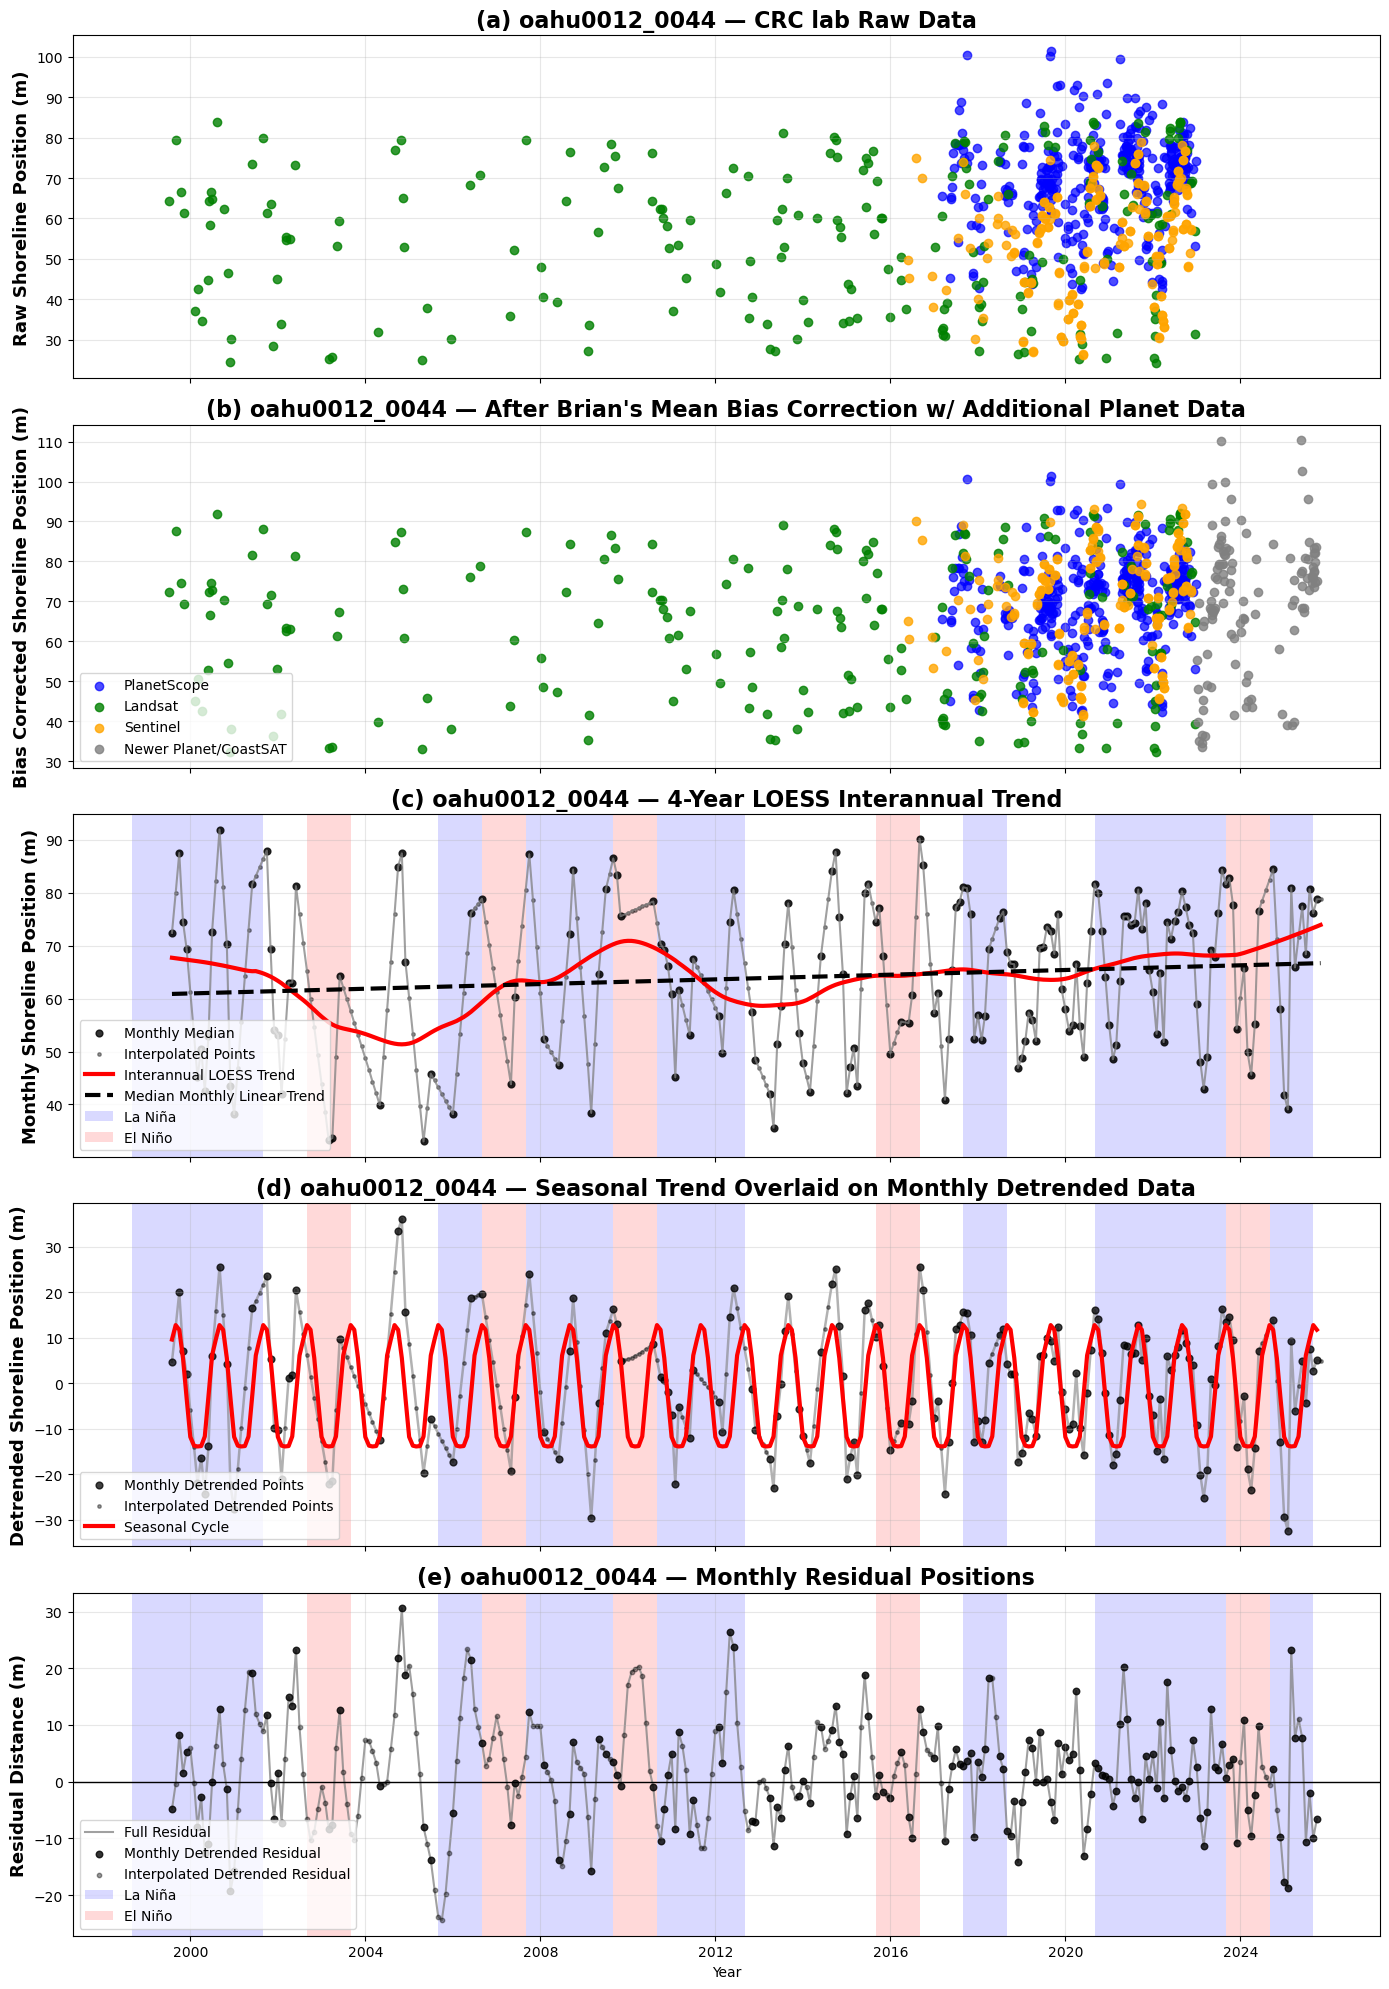

In [100]:
# df_transect = dataset[[transect]].copy() #monthly and rolling

# # ------------------------------------------------------------
# # CREATE 4 SUBPLOTS WITH SHARED X-AXIS
# # ------------------------------------------------------------
# fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
# (ax1, ax2, ax3, ax4, ax5) = axes

# #-----------------------------------------------------------
# # RAW PLANET COAST SAT DATA FROM CHIP
# # ----------------------------------------------------------
# # ---- ENSURE DATETIME INDEX ----
# df_planet.index = pd.to_datetime(df_planet.index)
# df_coastsat.index = pd.to_datetime(df_coastsat.index)

# df_planet_raw = df_planet.copy()


# # ---- SPLIT COASTSAT INTO LANDSAT & SENTINEL ----
# landsat_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("L")]
# sentinel_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("S")]


# # Planet (Blue)
# ax1.scatter(
#     df_planet_raw.index,
#     df_planet_raw[transect_col],
# color="blue", label="PlanetScope", alpha=0.7)

# # Landsat (Green)
# ax1.scatter(
#     landsat_df_raw.index,
#     landsat_df_raw[transect_col],
# color="green", label="Landsat (Bias Corrected)", alpha=0.8
# )

# # Sentinel (Orange)
# ax1.scatter(
#     sentinel_df_raw.index,
#     sentinel_df_raw[transect_col],
# color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)

# # ---- LABELS ----
# # ---- LABELS ----
# ax1.set_title(f"(a) {transect} — CRC lab Raw Data", fontweight="bold", fontsize=16)
# ax1.set_ylabel("Raw Shoreline Position (m)", fontweight="bold", fontsize=13)
# ax1.grid(alpha=0.3)
# # ============================================================
# # (a) FULL MONTHLY RECORD
# # ============================================================


# # ---- DEFINE DATE RANGE (match timezone automatically) ----
# tz = merged_corrected.index.tz

# # ---- SPLIT BY TYPE ----
# planet_df_corrected = df_plot[df_plot["type"] == "PLANET"]
# landsat_df_corrected = df_plot[df_plot["type"] == "LANDSAT"]
# sentinel_df_corrected = df_plot[df_plot["type"] == "SENTINEL"]

# # ---- CREATE FIGURE ----
# ax2.scatter(planet_df_corrected.index, planet_df_corrected[transect_col],
#             color="blue", label="PlanetScope", alpha=0.7)

# ax2.scatter(landsat_df_corrected.index, landsat_df_corrected[transect_col],
#             color="green", label="Landsat", alpha=0.8)

# ax2.scatter(sentinel_df_corrected.index, sentinel_df_corrected[transect_col],
#             color="orange", label="Sentinel", alpha=0.8)

# ax2.scatter(df_updated_new.index, df_updated_new[transect_col],
#             color="gray", label="Newer Planet/CoastSAT", alpha=0.8)


# ax2.set_title(f"(b) {transect} — After Brian's Mean Bias Correction w/ Additional Planet Data", fontweight="bold", fontsize=16)
# ax2.set_ylabel("Bias Corrected Shoreline Position (m)", fontweight="bold", fontsize=13)
# ax2.grid(alpha=0.3)
# ax2.legend(loc="lower left")


# # ax1.scatter(
# #     full_raw.index,
# #     full_raw[transect].values,
# #     s=22,
# #     alpha=0.7,
# #     color='steelblue',
# #     label='Shoreline Position'
# # )

# # ax1.set_title(f"(a) {transect} — Full Monthly Median Shoreline Record", fontsize=14)
# # ax1.set_ylabel("Shoreline Position (m)")
# # ax1.grid(alpha=0.3)
# # ax1.legend(loc="lower left")


# # ============================================================
# # (b) LOESS TREND PANEL
# # ============================================================


# # ---- ENSURE DATETIME INDEX ----
# series_orig.index = pd.to_datetime(series_orig.index)
# series_orig = series_orig.sort_index()

# # ---- REMOVE NaN VALUES FOR FITTING ----
# series_clean = series_orig.dropna()

# # ---- CONVERT DATES TO NUMERIC VALUES ----
# # This lets numpy fit a line through time
# x = series_clean.index.map(pd.Timestamp.toordinal).values
# y = series_clean.values

# # ---- FIT LINEAR TREND LINE ----
# slope, intercept = np.polyfit(x, y, 1)

# # ---- CREATE LINE VALUES ----
# x_line = series_orig.index.map(pd.Timestamp.toordinal).values
# y_line = slope * x_line + intercept


# ## LOESS Functions
# series_interp = series_orig.interpolate("linear")

# y = series_interp.values
# x = np.arange(len(y))
# frac = 48 / len(y)

# trend_vals = lowess(y, x, frac=frac, return_sorted=False)
# trend = pd.Series(trend_vals, index=series_interp.index)

# detrended_interannual = (series_orig - trend).dropna()
# detrended_full = (series_interp - trend).copy()

# raw_mask = series_orig.index
# interp_mask = detrended_full.index.difference(series_orig.index)

# ax3.plot(
#     series_interp.index,
#     series_interp.values,
#     color="gray",
#     alpha=0.75,
# )

# ax3.scatter(
#     series_orig.index,
#     series_orig.values,
#     s=24,
#     color='black',
#     alpha=0.8,
#     label='Monthly Median'
# )

# ax3.scatter(
#     series_interp.index,
#     series_interp.values,
#     s=6,
#     color='black',
#     alpha=0.4,
#     label='Interpolated Points'
# )

# ax3.plot(
#     trend.index,
#     trend.values,
#     color='red',
#     linewidth=3,
#     label='Interannual LOESS Trend'
# )

# # Best-fit straight line
# ax3.plot(
#     series_orig.index,
#     y_line,
#     color="black",
#     linewidth=3,
#     label="Median Monthly Linear Trend",
#     linestyle='--'
# )

# shade_enso(ax3, mei_summary, start_date, end_date, tz)

# ax3.set_title(f"(c) {transect} — 4-Year LOESS Interannual Trend", fontweight="bold", fontsize=16)
# ax3.set_ylabel("Monthly Shoreline Position (m)", fontweight="bold", fontsize=13)
# ax3.grid(alpha=0.3)
# ax3.legend(loc="lower left")


# # ============================================================
# # (c) DETRENDED + SEASONAL CYCLE
# # ============================================================

# d = detrended_interannual.copy()
# d.index = pd.to_datetime(d.index)

# seasonal_median = (
#     d.groupby(d.index.month)
#      .median()
#      .reindex(range(1,13))
# )

# months = np.arange(1,13)
# smooth_vals = lowess(
#     seasonal_median.values, months,
#     frac=0.45, xvals=months, return_sorted=False
# )
# smooth_cycle = pd.Series(smooth_vals, index=months)

# start = d.index.min().normalize()
# end   = d.index.max().normalize()
# full_month_index = pd.date_range(start=start, end=end, freq="M")

# seasonal_full = pd.Series(
#     [smooth_cycle[m] for m in full_month_index.month],
#     index=full_month_index,
#     name="Sy_full"
# )

# raw_mask = d.index
# interp_mask = detrended_full.index.difference(d.index)

# ax4.plot(
#     detrended_full.index,
#     detrended_full.values,
#     color="gray",
#     alpha=0.6,
#     linewidth=1.8,
#     zorder=1,
# )

# ax4.scatter(
#     raw_mask,
#     d.values,
#     s=24,
#     alpha=0.75,
#     color="black",
#     label="Monthly Detrended Points"
# )

# ax4.scatter(
#     interp_mask,
#     detrended_full.loc[interp_mask].values,
#     s=6,
#     color='black',
#     alpha=0.4,
#     label="Interpolated Detrended Points"
# )

# ax4.plot(
#     seasonal_full.index,
#     seasonal_full.values,
#     color="red",
#     linewidth=3,
#     label="Seasonal Cycle"
# )

# for _, row in mei_summary.iterrows():

#     season = row["season_year"]
#     label = row["ENSO_label"]

#     # Skip neutral years
#     if label == "NEUTRAL":
#         continue

#     # Extract start and end year from string like "1999-2000"
#     start_year, end_year = season.split("-")
#     start_year = int(start_year)
#     end_year = int(end_year)

#     # Define ENSO season window
#     enso_start = pd.Timestamp(f"{start_year}-09-01")
#     enso_end = pd.Timestamp(f"{end_year}-08-31")

#     # Match timezone if needed
#     if tz is not None:
#         enso_start = enso_start.tz_localize(tz)
#         enso_end = enso_end.tz_localize(tz)

#     # Only shade seasons that overlap your plotting period
#     if enso_end < start_date or enso_start > end_date:
#         continue

#     if label == "POSITIVE":   # El Niño
#         ax4.axvspan(
#             enso_start,
#             enso_end,
#             color="red",
#             alpha=0.15,
#             linewidth=0,
#             edgecolor="none",
#             zorder=0
#         )
    
#     elif label == "NEGATIVE": # La Niña
#         ax4.axvspan(
#             enso_start,
#             enso_end,
#             color="blue",
#             alpha=0.15,
#             linewidth=0,
#             edgecolor="none",
#             zorder=0
#         )

# ax4.set_title(f"(d) {transect} — Seasonal Trend Overlaid on Monthly Detrended Data", fontweight="bold", fontsize=16)
# ax4.set_ylabel("Detrended Shoreline Position (m)", fontweight="bold", fontsize=13)
# ax4.grid(alpha=0.3)
# ax4.legend(loc="lower left")


# # ============================================================
# # (d) RESIDUAL (Ry)
# # ============================================================

# Ry_full = detrended_full - seasonal_full.reindex(detrended_full.index)

# Ry_raw = Ry_full.loc[raw_mask]
# Ry_interp = Ry_full.loc[interp_mask]

# ax5.plot(
#     Ry_full.index, Ry_full.values,
#     color="gray", alpha=0.75, zorder=1,
#     label="Full Residual"
# )

# ax5.scatter(
#     Ry_raw.index, Ry_raw.values,
#     s=22, color="black", alpha=0.8,
#     label="Monthly Detrended Residual"
# )

# ax5.scatter(
#     Ry_interp.index, Ry_interp.values,
#     s=10, color="black", alpha=0.4,
#     label="Interpolated Detrended Residual"
# )

# shade_enso(ax5, mei_summary, start_date, end_date, tz)
        
# ax5.axhline(0, color="black", linewidth=1)
# ax5.set_title(f"(e) {transect} — Monthly Residual Positions", fontweight="bold", fontsize=16)
# ax5.set_ylabel("Residual Distance (m)", fontweight="bold", fontsize=13)
# ax5.set_xlabel("Year")
# ax5.grid(alpha=0.3)
# ax5.legend(loc="lower left")




# # ------------------------------------------------------------
# # FINAL LAYOUT
# # ------------------------------------------------------------
# plt.tight_layout()
# plt.gcf().savefig(os.path.join("Brian_figs", "shoreline_decomposition" +transect+".png"), dpi=300, bbox_inches="tight")
# plt.show()


In [134]:
transect_col = 'oahu0012_0063'
full_raw = merged_final[merged_final.index >= "1999-07-01"][[transect]].copy()
dataset = monthly_median_planet_coast
monthly_medians_stats = monthly_medians_stats_raw.copy()

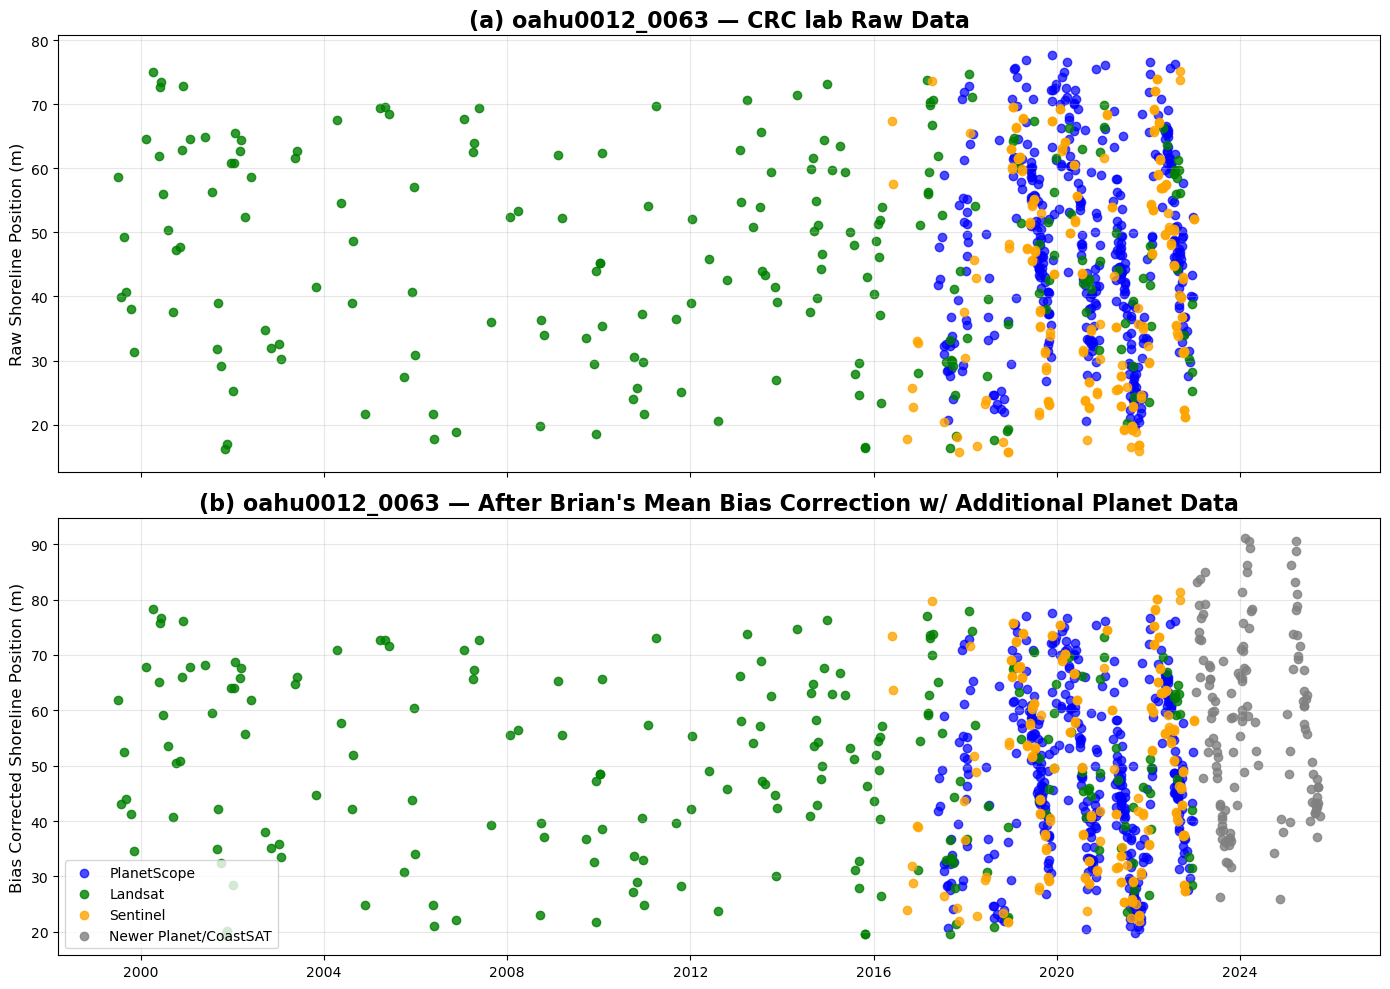

In [139]:
df_transect = dataset[[transect]].copy() #monthly and rolling

# ------------------------------------------------------------
# CREATE 4 SUBPLOTS WITH SHARED X-AXIS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
(ax1, ax2) = axes

#-----------------------------------------------------------
# RAW PLANET COAST SAT DATA FROM CHIP
# ----------------------------------------------------------
# ---- ENSURE DATETIME INDEX ----
df_planet.index = pd.to_datetime(df_planet.index)
df_coastsat.index = pd.to_datetime(df_coastsat.index)

df_planet_raw = df_planet.copy()


# ---- SPLIT COASTSAT INTO LANDSAT & SENTINEL ----
landsat_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("L")]
sentinel_df_raw = df_coastsat[df_coastsat["satname"].str.startswith("S")]


# Planet (Blue)
ax1.scatter(
    df_planet_raw.index,
    df_planet_raw[transect_col],
color="blue", label="PlanetScope", alpha=0.7)

# Landsat (Green)
ax1.scatter(
    landsat_df_raw.index,
    landsat_df_raw[transect_col],
color="green", label="Landsat (Bias Corrected)", alpha=0.8
)

# Sentinel (Orange)
ax1.scatter(
    sentinel_df_raw.index,
    sentinel_df_raw[transect_col],
color="orange", label="Sentinel (Bias Corrected)", alpha=0.8)

# ---- LABELS ----
# ---- LABELS ----
ax1.set_title(f"(a) {transect} — CRC lab Raw Data", fontweight="bold", fontsize=16)
ax1.set_ylabel("Raw Shoreline Position (m)", fontsize=12)
ax1.grid(alpha=0.3)
# ============================================================
# (a) FULL MONTHLY RECORD
# ============================================================


# ---- DEFINE DATE RANGE (match timezone automatically) ----
tz = merged_corrected.index.tz

# ---- SPLIT BY TYPE ----
planet_df_corrected = df_plot[df_plot["type"] == "PLANET"]
landsat_df_corrected = df_plot[df_plot["type"] == "LANDSAT"]
sentinel_df_corrected = df_plot[df_plot["type"] == "SENTINEL"]

# ---- CREATE FIGURE ----
ax2.scatter(planet_df_corrected.index, planet_df_corrected[transect_col],
            color="blue", label="PlanetScope", alpha=0.7)

ax2.scatter(landsat_df_corrected.index, landsat_df_corrected[transect_col],
            color="green", label="Landsat", alpha=0.8)

ax2.scatter(sentinel_df_corrected.index, sentinel_df_corrected[transect_col],
            color="orange", label="Sentinel", alpha=0.8)

ax2.scatter(df_updated_new.index, df_updated_new[transect_col],
            color="gray", label="Newer Planet/CoastSAT", alpha=0.8)


ax2.set_title(f"(b) {transect} — After Brian's Mean Bias Correction w/ Additional Planet Data", fontweight="bold", fontsize=16)
ax2.set_ylabel("Bias Corrected Shoreline Position (m)", fontsize=12)
ax2.grid(alpha=0.3)
ax2.legend(loc="lower left")


# ax1.scatter(
#     full_raw.index,
#     full_raw[transect].values,
#     s=22,
#     alpha=0.7,
#     color='steelblue',
#     label='Shoreline Position'
# )

# ax1.set_title(f"(a) {transect} — Full Monthly Median Shoreline Record", fontsize=14)
# ax1.set_ylabel("Shoreline Position (m)")
# ax1.grid(alpha=0.3)
# ax1.legend(loc="lower left")



# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", "mean_bias_correction_" +transect+".png"), dpi=300, bbox_inches="tight")
plt.show()


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2357747939.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2357747939.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2360679574.py:125: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_month_index = pd.date_range(start=start, end=end, freq="M")
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2360679574.py:210: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax4.axvspan(
C:\Users\bgorberg\AppData\Local\Temp\ipykernel_10036\2360679574.py:199: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax4.axvspan(


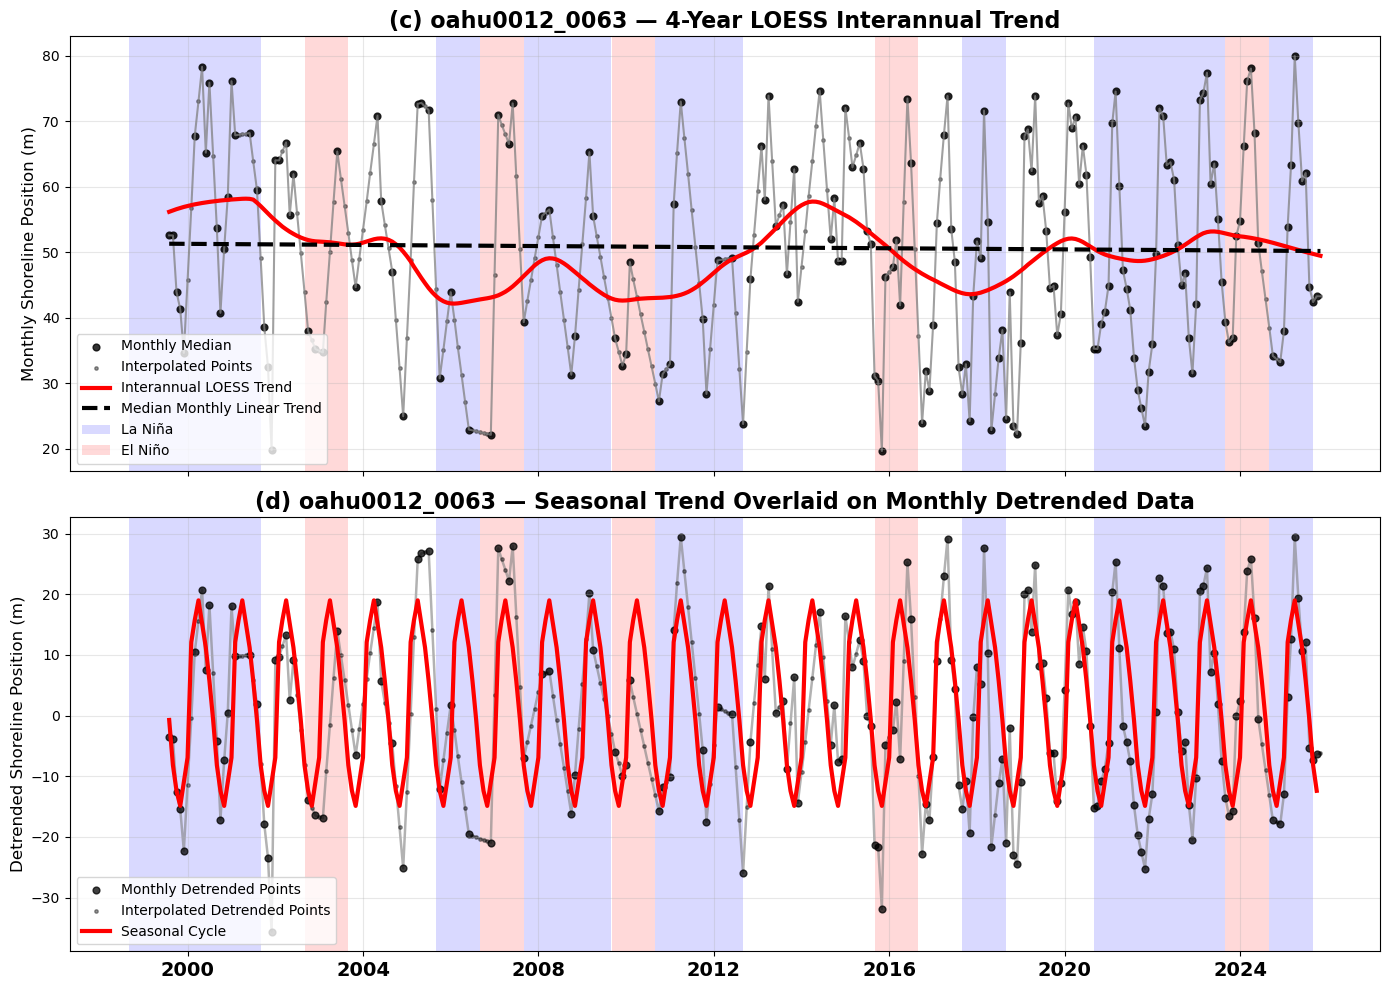

In [140]:
df_transect = dataset[[transect_col]].copy() #monthly and rolling

# ------------------------------------------------------------
# CREATE 4 SUBPLOTS WITH SHARED X-AXIS
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
(ax3, ax4) = axes

# ============================================================
# (b) LOESS TREND PANEL
# ============================================================
series_orig = df_transect.squeeze()
series_orig.index = pd.to_datetime(series_orig.index)
series_orig = series_orig.sort_index()

# ---- ENSURE DATETIME INDEX ----
series_orig.index = pd.to_datetime(series_orig.index)
series_orig = series_orig.sort_index()

# ---- REMOVE NaN VALUES FOR FITTING ----
series_clean = series_orig.dropna()

# ---- CONVERT DATES TO NUMERIC VALUES ----
# This lets numpy fit a line through time
x = series_clean.index.map(pd.Timestamp.toordinal).values
y = series_clean.values

# ---- FIT LINEAR TREND LINE ----
slope, intercept = np.polyfit(x, y, 1)

# ---- CREATE LINE VALUES ----
x_line = series_orig.index.map(pd.Timestamp.toordinal).values
y_line = slope * x_line + intercept


## LOESS Functions
series_interp = series_orig.interpolate("linear")

y = series_interp.values
x = np.arange(len(y))
frac = 48 / len(y)

trend_vals = lowess(y, x, frac=frac, return_sorted=False)
trend = pd.Series(trend_vals, index=series_interp.index)

detrended_interannual = (series_orig - trend).dropna()
detrended_full = (series_interp - trend).copy()

raw_mask = series_orig.index
interp_mask = detrended_full.index.difference(series_orig.index)

ax3.plot(
    series_interp.index,
    series_interp.values,
    color="gray",
    alpha=0.75,
)

ax3.scatter(
    series_orig.index,
    series_orig.values,
    s=24,
    color='black',
    alpha=0.8,
    label='Monthly Median'
)

ax3.scatter(
    series_interp.index,
    series_interp.values,
    s=6,
    color='black',
    alpha=0.4,
    label='Interpolated Points'
)

ax3.plot(
    trend.index,
    trend.values,
    color='red',
    linewidth=3,
    label='Interannual LOESS Trend'
)

# Best-fit straight line
ax3.plot(
    series_orig.index,
    y_line,
    color="black",
    linewidth=3,
    label="Median Monthly Linear Trend",
    linestyle='--'
)

shade_enso(ax3, mei_summary, start_date, end_date, tz)

ax3.set_title(f"(c) {transect_col} — 4-Year LOESS Interannual Trend", fontweight="bold", fontsize=16)
ax3.set_ylabel("Monthly Shoreline Position (m)", fontsize=12)
ax3.grid(alpha=0.3)
ax3.legend(loc="lower left")


# ============================================================
# (c) DETRENDED + SEASONAL CYCLE
# ============================================================

d = detrended_interannual.copy()
d.index = pd.to_datetime(d.index)

seasonal_median = (
    d.groupby(d.index.month)
     .median()
     .reindex(range(1,13))
)

months = np.arange(1,13)
smooth_vals = lowess(
    seasonal_median.values, months,
    frac=0.45, xvals=months, return_sorted=False
)
smooth_cycle = pd.Series(smooth_vals, index=months)

start = d.index.min().normalize()
end   = d.index.max().normalize()
full_month_index = pd.date_range(start=start, end=end, freq="M")

seasonal_full = pd.Series(
    [smooth_cycle[m] for m in full_month_index.month],
    index=full_month_index,
    name="Sy_full"
)

raw_mask = d.index
interp_mask = detrended_full.index.difference(d.index)

ax4.plot(
    detrended_full.index,
    detrended_full.values,
    color="gray",
    alpha=0.6,
    linewidth=1.8,
    zorder=1,
)

ax4.scatter(
    raw_mask,
    d.values,
    s=24,
    alpha=0.75,
    color="black",
    label="Monthly Detrended Points"
)

ax4.scatter(
    interp_mask,
    detrended_full.loc[interp_mask].values,
    s=6,
    color='black',
    alpha=0.4,
    label="Interpolated Detrended Points"
)

ax4.plot(
    seasonal_full.index,
    seasonal_full.values,
    color="red",
    linewidth=3,
    label="Seasonal Cycle"
)

for _, row in mei_summary.iterrows():

    season = row["season_year"]
    label = row["ENSO_label"]

    # Skip neutral years
    if label == "NEUTRAL":
        continue

    # Extract start and end year from string like "1999-2000"
    start_year, end_year = season.split("-")
    start_year = int(start_year)
    end_year = int(end_year)

    # Define ENSO season window
    enso_start = pd.Timestamp(f"{start_year}-09-01")
    enso_end = pd.Timestamp(f"{end_year}-08-31")

    # Match timezone if needed
    if tz is not None:
        enso_start = enso_start.tz_localize(tz)
        enso_end = enso_end.tz_localize(tz)

    # Only shade seasons that overlap your plotting period
    if enso_end < start_date or enso_start > end_date:
        continue

    if label == "POSITIVE":   # El Niño
        ax4.axvspan(
            enso_start,
            enso_end,
            color="red",
            alpha=0.15,
            linewidth=0,
            edgecolor="none",
            zorder=0
        )
    
    elif label == "NEGATIVE": # La Niña
        ax4.axvspan(
            enso_start,
            enso_end,
            color="blue",
            alpha=0.15,
            linewidth=0,
            edgecolor="none",
            zorder=0
        )

ax4.set_title(f"(d) {transect_col} — Seasonal Trend Overlaid on Monthly Detrended Data", fontweight="bold", fontsize=16)
ax4.set_ylabel("Detrended Shoreline Position (m)", fontsize=12)
ax4.grid(alpha=0.3)
ax4.legend(loc="lower left")



for ax in axes:
    ax.tick_params(axis="x", labelsize=14)

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")

# ------------------------------------------------------------
# FINAL LAYOUT
# ------------------------------------------------------------
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", "LOESS_seasonal" +transect+".png"), dpi=300, bbox_inches="tight")
plt.show()

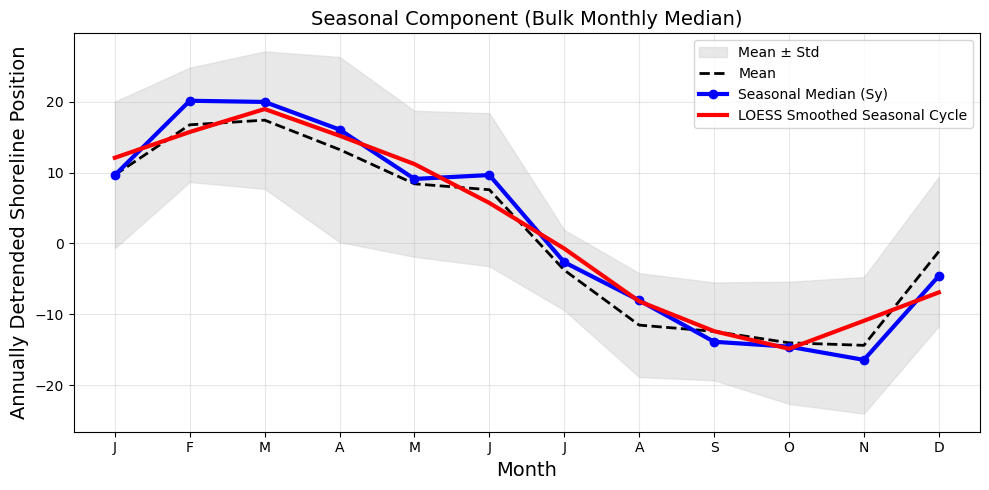

In [141]:
# -----------------------------------------------
# 1. RAW DETRENDED DATA (Sy + Ry)
# -----------------------------------------------
d = detrended_interannual.copy()
d.index = pd.to_datetime(d.index)

# -----------------------------------------------
# 2. MONTHLY STATISTICS
# -----------------------------------------------
seasonal_median = d.groupby(d.index.month).median().reindex(range(1,13))
seasonal_mean   = d.groupby(d.index.month).mean().reindex(range(1,13))
seasonal_std    = d.groupby(d.index.month).std().reindex(range(1,13))

months = np.arange(1,13)

# -----------------------------------------------
# 3. LOESS SMOOTH OF SEASONAL MEDIAN
# -----------------------------------------------
smooth_vals = lowess(
    seasonal_median.values,
    months,
    frac=0.45,
    xvals=months,
    return_sorted=False
)

smooth_cycle = pd.Series(smooth_vals, index=months)

# -----------------------------------------------
# 4. PLOT SEASONAL COMPONENT
# -----------------------------------------------
plt.figure(figsize=(10,5))

# Std shading
plt.fill_between(
    months,
    seasonal_mean - seasonal_std,
    seasonal_mean + seasonal_std,
    color='lightgray', alpha=0.5,
    label='Mean ± Std'
)

# Mean line
plt.plot(months, seasonal_mean, "k--", lw=2, label="Mean")

# Raw monthly medians
plt.plot(months, seasonal_median, "o-", lw=3, color="blue", label="Seasonal Median (Sy)")

# -----------------------------------------------
# LOESS-smoothed seasonal curve (RED)
# -----------------------------------------------
plt.plot(
    months,
    smooth_cycle.values,
    color="red",
    linewidth=3,
    label="LOESS Smoothed Seasonal Cycle"
)

# Formatting
plt.xticks(months, ["J","F","M","A","M","J","J","A","S","O","N","D"])
plt.title("Seasonal Component (Bulk Monthly Median)", fontsize=14)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Annually Detrended Shoreline Position", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.gcf().savefig(os.path.join("Brian_figs", f"shoreline_bulkmonthlymedian_{transect}.png"),
                  dpi=300, bbox_inches="tight")

plt.show()


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13892\158577749.py:109: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  full_month_index = pd.date_range(start=start, end=end, freq="M")


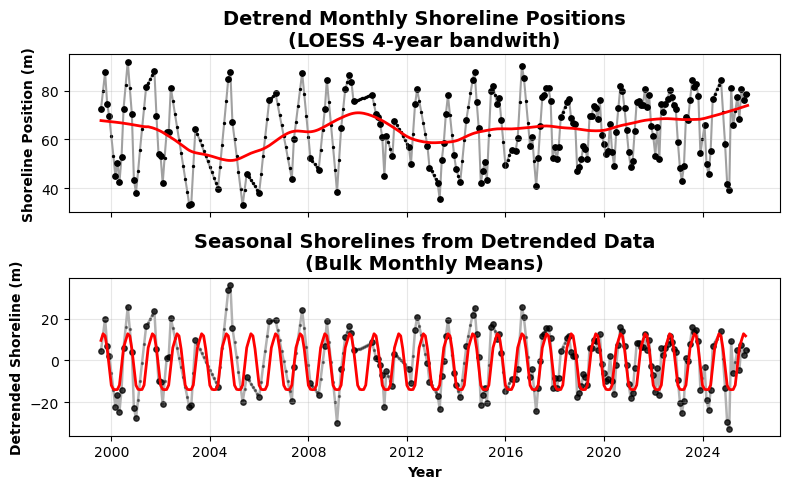

In [45]:
# df_transect = dataset[[transect]].copy()

# # ------------------------------------------------------------
# # CREATE 2 SUBPLOTS
# # ------------------------------------------------------------
# fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
# (ax1, ax2) = axes


# # ============================================================
# # (b) LOESS TREND PANEL
# # ============================================================

# series_orig = df_transect[transect].sort_index()
# series_orig.index = pd.to_datetime(series_orig.index)

# series_interp = series_orig.interpolate("linear")

# y = series_interp.values
# x = np.arange(len(y))
# frac = 48 / len(y)

# trend_vals = lowess(y, x, frac=frac, return_sorted=False)
# trend = pd.Series(trend_vals, index=series_interp.index)

# detrended_interannual = (series_orig - trend).dropna()
# detrended_full = (series_interp - trend).copy()

# raw_mask = series_orig.index
# interp_mask = detrended_full.index.difference(series_orig.index)

# ax1.plot(
#     series_interp.index,
#     series_interp.values,
#     color="gray",
#     alpha=0.75,
#     zorder=1,
#     label="Interpolated Shoreline"
# )

# ax1.scatter(
#     series_orig.index,
#     series_orig.values,
#     s=15,
#     color='black',
#     alpha=1,
#     label='Monthly Median'
# )

# ax1.scatter(
#     series_interp.index,
#     series_interp.values,
#     s=2,
#     color='black',
#     alpha=1,
#     label='Interpolated Points'
# )

# ax1.plot(
#     trend.index,
#     trend.values,
#     color='red',
#     linewidth=2,
#     label='Annual Trend'
# )

# ax1.set_title(
#     "Detrend Monthly Shoreline Positions\n(LOESS 4-year bandwith)",
#     fontweight="bold", fontsize =14
# )

# ax1.set_ylabel(
#     "Shoreline Position (m)",
#     fontweight="bold"
# )

# ax1.grid(alpha=0.3)
# #ax1.legend(loc="lower left")


# # ============================================================
# # (c) DETRENDED + SEASONAL CYCLE
# # ============================================================

# d = detrended_interannual.copy()
# d.index = pd.to_datetime(d.index)

# seasonal_median = (
#     d.groupby(d.index.month)
#      .median()
#      .reindex(range(1,13))
# )

# months = np.arange(1,13)

# smooth_vals = lowess(
#     seasonal_median.values,
#     months,
#     frac=0.45,
#     xvals=months,
#     return_sorted=False
# )

# smooth_cycle = pd.Series(smooth_vals, index=months)

# start = d.index.min().normalize()
# end   = d.index.max().normalize()

# full_month_index = pd.date_range(start=start, end=end, freq="M")

# seasonal_full = pd.Series(
#     [smooth_cycle[m] for m in full_month_index.month],
#     index=full_month_index
# )

# raw_mask = d.index
# interp_mask = detrended_full.index.difference(d.index)

# ax2.plot(
#     detrended_full.index,
#     detrended_full.values,
#     color="gray",
#     alpha=0.6,
#     linewidth=1.8,
#     label="Annual Detrend",
#     zorder=0
# )

# ax2.scatter(
#     raw_mask,
#     d.values,
#     s=15,
#     alpha=0.75,
#     color="black",
#     label="Raw Detrend"
# )

# ax2.scatter(
#     interp_mask,
#     detrended_full.loc[interp_mask].values,
#     s=2,
#     color='black',
#     alpha=0.4,
#     label="Interp Detrend"
# )

# ax2.plot(
#     seasonal_full.index,
#     seasonal_full.values,
#     color="red",
#     linewidth=2,
#     label="Seasonal Cycle"
# )

# ax2.set_title(
#     "Seasonal Shorelines from Detrended Data\n(Bulk Monthly Means)",
#     fontweight="bold", fontsize = 14
# )

# ax2.set_ylabel(
#     "Detrended Shoreline (m)",
#     fontweight="bold"
# )

# ax2.set_xlabel(
#     "Year",
#     fontweight="bold"
# )

# ax2.grid(alpha=0.3)
# #ax2.legend(loc="lower left")
# # ============================================================
# # (d) RESIDUAL (Ry)
# # ============================================================

# Ry_full = detrended_full - seasonal_full.reindex(detrended_full.index)

# Ry_raw = Ry_full.loc[raw_mask]
# Ry_interp = Ry_full.loc[interp_mask]

# ax4.plot(
#     Ry_full.index, Ry_full.values,
#     color="green", alpha=0.75, zorder=1,
#     label="Full Residual"
# )

# ax4.scatter(
#     Ry_raw.index, Ry_raw.values,
#     s=22, color="blue", alpha=0.8,
#     label="Raw Residual"
# )

# ax4.scatter(
#     Ry_interp.index, Ry_interp.values,
#     s=10, color="blue", alpha=0.4,
#     label="Interp Residual"
# )

# ax4.axhline(0, color="black", linewidth=1)
# ax4.set_title(f"(d) {transect} — Monthly Residual Positions (Ry)")
# ax4.set_ylabel("Residue (m)")
# ax4.set_xlabel("Date")
# ax4.grid(alpha=0.3)
# ax4.legend(loc="lower left")

# # ------------------------------------------------------------
# # FINAL LAYOUT
# # ------------------------------------------------------------
# plt.tight_layout()

# plt.savefig(
#     os.path.join("Brian_figs", f"shoreline_trend_seasonal_{transect}.png"),
#     dpi=300,
#     bbox_inches="tight"
# )

# plt.show()

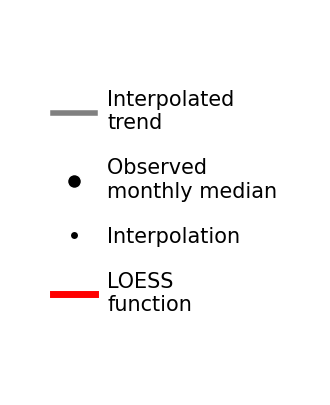

In [17]:
legend_elements = [
    Line2D([0],[0], color="gray", lw=4, label="Interpolated \ntrend"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=10, label="Observed \nmonthly median"),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='black',
           markersize=6, label="Interpolation"),
    Line2D([0],[0], color="red", lw=5, label="LOESS \nfunction")
]

fig_leg = plt.figure(figsize=(4,5))

fig_leg.legend(
    handles=legend_elements,
    loc="center",
    ncol=1,                 # vertical stack
    frameon=False,
    columnspacing=0.8,
    handletextpad=0.6,
    handlelength=2,       # longer bars
    labelspacing=1.2,       # tighter stacking
    fontsize=15
)

plt.axis("off")

plt.savefig(
    os.path.join("Brian_figs","legend.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evaluate Bulk Monthly Medians

# Loop through data: interpolate, detrend annual, determine seasonal cycle: tmax month, tmin month, tmin median, tmax median, stat test (1= significant)

In [19]:
# selecting the transect and following the detrending procedure for annual
seasonal_stats_storage = {
    'transect': [],
    'tmin_month': [],
    'tmax_month': [],
    'tmin_median': [],
    'tmax_median': [],
    't_maxmin_difference': [],
    't_test_results': [],
    'monthly_medians': []   # <-- NEW COLUMN
}

lst = list(range(1, last_transect_number + 1))

for i in lst:
    transect = generate_transect_list(start_transect=i, end_transect=i)[0]
    df_transect = dataset[[transect]].copy()
    
    series_orig = dataset[transect].sort_index()
    series_orig.index = pd.to_datetime(series_orig.index)
    
    series_interp = series_orig.interpolate("linear")
    
    y = series_interp.values
    x = np.arange(len(y))
    frac = 48 / len(y)
    
    trend_vals = lowess(y, x, frac=frac, return_sorted=False)
    trend = pd.Series(trend_vals, index=series_interp.index)
    
    detrended_interannual = (series_orig - trend).dropna()
    
    # -----------------------------------------------
    # 2. MONTHLY STATISTICS
    # -----------------------------------------------
    seasonal_median_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).median().reindex(range(1, 13))

    seasonal_mean_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).mean().reindex(range(1, 13))

    seasonal_std_months = detrended_interannual.groupby(
        detrended_interannual.index.month
    ).std().reindex(range(1, 13))


    # tmin and tmax
    tmin_month = seasonal_median_months.idxmin()
    tmin_position = seasonal_median_months.min()
    tmax_month = seasonal_median_months.idxmax()
    tmax_position = seasonal_median_months.max()

    # T-TEST significance
    months = detrended_interannual.index.month
    values_tmin = detrended_interannual[months == tmin_month]
    values_tmax = detrended_interannual[months == tmax_month]

    t_stat, p_value = ttest_ind(values_tmin, values_tmax, equal_var=False)
    stat_test = 1 if p_value < 0.05 else 0


    #standardize the monthly median values
    # Convert list → numpy array first
    arr = np.array(seasonal_median_months.values.tolist(), dtype=float)
    
    avg = arr.mean()
    std = arr.std()
    
    standardized_medians = (arr - avg) / std

        #ADD TO STORAGE
    seasonal_stats_storage['transect'].append(transect)
    seasonal_stats_storage['tmin_month'].append(tmin_month)
    seasonal_stats_storage['tmax_month'].append(tmax_month)
    seasonal_stats_storage['tmin_median'].append(tmin_position)
    seasonal_stats_storage['tmax_median'].append(tmax_position)
    seasonal_stats_storage['t_test_results'].append(stat_test)
    seasonal_stats_storage['t_maxmin_difference'].append(tmax_position - tmin_position)
        # === NEW: append 12-month vector ===
    seasonal_stats_storage["monthly_medians"].append(
        standardized_medians
    )


# Convert to dataframe
seasonal_stats_storage = pd.DataFrame(seasonal_stats_storage)

# Merge
merged_stats = monthly_medians_stats.merge(
    seasonal_stats_storage,
    on="transect",
    how="inner"
)

# Standardize amplitude
merged_stats['min_max_diff_standardized'] = (
    merged_stats['t_maxmin_difference'] - merged_stats['baseline_average']
) / merged_stats['baseline_std']

# Zero out amplitude for nonseasonal
merged_stats.loc[
    merged_stats['t_test_results'] == 0,
    'monthly_medians'
] = merged_stats.loc[
        merged_stats['t_test_results'] == 0,
        'monthly_medians'
    ].apply(lambda x: [0]*12)



In [20]:
merged_stats.t_test_results.value_counts()

t_test_results
1    242
0      4
Name: count, dtype: int64

# Apply K means to group transects

In [21]:
# Make sure every entry is a 1D array of length 12
def to_1d_array(x):
    arr = np.asarray(x).ravel()
    if arr.shape[0] != 12:
        raise ValueError(f"Found monthly_medians with length {arr.shape[0]} instead of 12")
    return arr

monthly_arrays = merged_stats["monthly_medians"].apply(to_1d_array)

# Stack into 2D matrix
monthly_matrix_z = np.vstack(monthly_arrays.to_list())
print("monthly_matrix_z shape:", monthly_matrix_z.shape)
# --------------------------------------------------
# 1. Extract standardized 12-month medians from storage
# --------------------------------------------------
monthly_matrix_z = np.array(merged_stats["monthly_medians"].to_list())
# shape: (N, 12)

# Sanity check
assert monthly_matrix_z.shape[1] == 12, "Each entry must contain 12 months"

# --------------------------------------------------
# 2. Compute month angles (1..12)
# --------------------------------------------------
months = np.arange(1, 13)
theta = 2 * np.pi * months / 12

month_sin = np.sin(theta)   # shape (12,)
month_cos = np.cos(theta)   # shape (12,)

# --------------------------------------------------
# 3. Build **modulated** circular features (correct 24-feature form)
# --------------------------------------------------
sin_features = monthly_matrix_z * month_sin          # (N × 12)
cos_features = monthly_matrix_z * month_cos          # (N × 12)

# --------------------------------------------------
# 4. Final feature matrix (N × 24)
# --------------------------------------------------
features = np.hstack([sin_features, cos_features])

print("Final feature matrix shape:", features.shape)
# should be (N, 24)


monthly_matrix_z shape: (246, 12)
Final feature matrix shape: (246, 24)


In [22]:
from sklearn.cluster import KMeans

k = 11 # from the paper

kmeans = KMeans(
    n_clusters=k,
    n_init=50,        # many random initializations = stable clusters
    max_iter=1000,    # more iterations = better convergence
    random_state=42
)

cluster_labels = kmeans.fit_predict(features)
merged_stats["cluster_label"] = cluster_labels

C:\Users\bgorberg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\bgorberg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\bgorberg\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _w

In [23]:
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0, "cluster_label"
].unique()

Nonseasonal clusters: [4]


=== Correct Seasonal Cluster Order ===
Cluster 7: mean min-month ≈ 1.00
Cluster 2: mean min-month ≈ 3.08
Cluster 9: mean min-month ≈ 4.25
Cluster 1: mean min-month ≈ 5.52
Cluster 8: mean min-month ≈ 5.63
Cluster 10: mean min-month ≈ 6.00
Cluster 3: mean min-month ≈ 7.79
Cluster 6: mean min-month ≈ 8.00
Cluster 5: mean min-month ≈ 8.40
Cluster 0: mean min-month ≈ 9.85
Cluster 4: mean min-month ≈ inf
    cluster_label  mean_max_month
0               7            1.00
1               2            3.08
2               9            4.25
3               1            5.52
4               8            5.63
5              10            6.00
6               3            7.79
7               6            8.00
8               5            8.40
9               0            9.85
10              4             inf


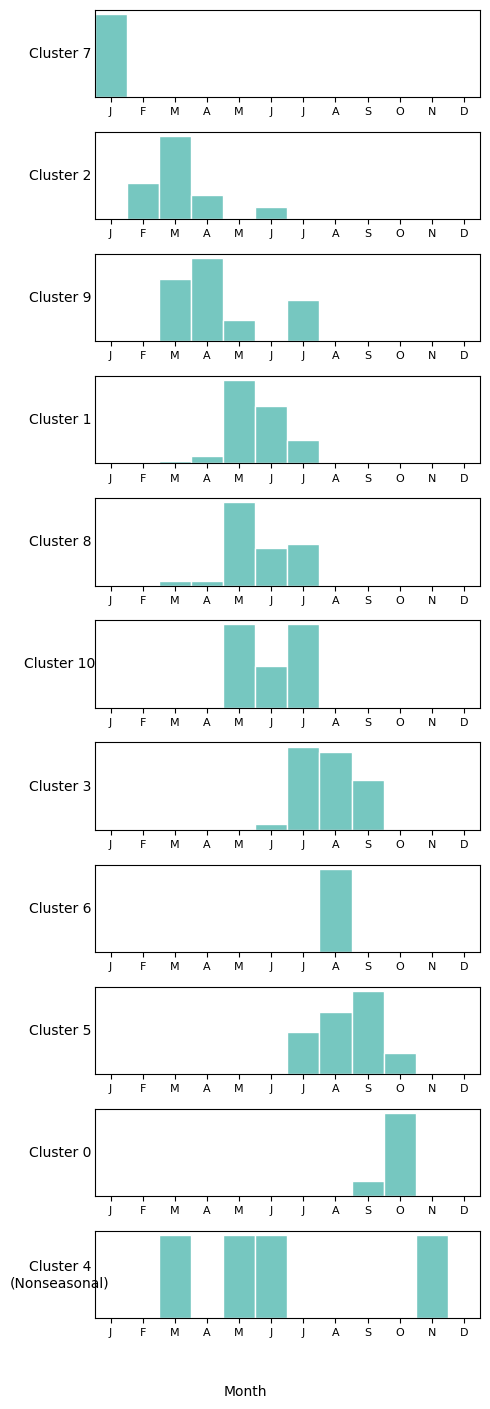

In [24]:
cluster_labels = merged_stats["cluster_label"].values
tmax_month = merged_stats["tmax_month"].values
unique_clusters = np.unique(cluster_labels)
month_labels = ["J","F","M","A","M","J","J","A","S","O","N","D"]

# -------------------------------------------------------
# STEP 1 — Identify nonseasonal clusters using t_test_results == 0
# -------------------------------------------------------
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0, "cluster_label"
].unique()

print("Nonseasonal clusters:", nonseasonal_clusters)

# -------------------------------------------------------
# STEP 2 — Compute mean-month per cluster (ignore nonseasonal)
# -------------------------------------------------------
import numpy as np

def circular_mean_month(months):
    """
    Compute circular mean of months (1–12) using radians.
    Returns mean month in range 1–12.
    """
    if len(months) == 0:
        return np.nan

    # Convert months to radians
    theta = 2 * np.pi * (months - 1) / 12

    mean_sin = np.mean(np.sin(theta))
    mean_cos = np.mean(np.cos(theta))

    mean_angle = np.arctan2(mean_sin, mean_cos)

    # Convert back to 1–12 month scale
    mean_month = ((mean_angle / (2 * np.pi)) * 12) + 1
    if mean_month <= 0:
        mean_month += 12

    return mean_month


# ---------------------------------------------------
# Compute circular mean month for each cluster
# ---------------------------------------------------
cluster_mean_month = {}

unique_clusters = np.unique(cluster_labels)

for cid in unique_clusters:

    # Extract months for this cluster
    months = tmax_month[cluster_labels == cid]

    if cid in nonseasonal_clusters:      # nonseasonal class (flat pattern)
        cluster_mean_month[cid] = np.inf # push to END
    else:
        cluster_mean_month[cid] = circular_mean_month(months)

# ---------------------------------------------------
# Sort clusters by circular seasonal order
# ---------------------------------------------------
sorted_clusters = sorted(
    cluster_mean_month.keys(),
    key=lambda c: cluster_mean_month[c]
)

print("\n\n=== Correct Seasonal Cluster Order ===")
for c in sorted_clusters:
    print(f"Cluster {c}: mean min-month ≈ {cluster_mean_month[c]:.2f}")

cluster_mean_month_df = pd.DataFrame({
    "cluster_label": sorted_clusters,
    "mean_max_month": [round(cluster_mean_month[c], 2) for c in sorted_clusters]
})

print(cluster_mean_month_df)

# -------------------------------------------------------
# STEP 3 — Plot
# -------------------------------------------------------
fig, axes = plt.subplots(len(sorted_clusters), 1, figsize=(5, len(sorted_clusters) * 1.3))

for i, cluster_id in enumerate(sorted_clusters):
    ax = axes[i]
    data = tmax_month[cluster_labels == cluster_id]

    bins = np.arange(1, 14)
    ax.hist(data, bins=bins, color="#76c7c0", edgecolor="white")

    ax.set_xlim(1, 13)
    ax.set_xticks(np.arange(1.5, 13.5, 1))
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_yticks([])

    # Label: add "Nonseasonal" if applicable
    if cluster_id in nonseasonal_clusters:
        label_text = f"Cluster {cluster_id}\n(Nonseasonal)"
    else:
        label_text = f"Cluster {cluster_id}"

    ax.set_ylabel(label_text, rotation=0, labelpad=25, va='center')

fig.text(0.5, 0.02, "Month", ha='center', fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])

# SAVE BEFORE SHOWING
os.makedirs("Brian_figs", exist_ok=True)
fig.savefig(
    os.path.join("Brian_figs", "clusters_tmax.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
merged_stats = merged_stats.merge(
    cluster_mean_month_df,
    on="cluster_label",
    how="left"
)

In [26]:
# Inputs
cluster_labels = merged_stats["cluster_label"].values
tmax_month = merged_stats["tmax_month"].values
unique_clusters = np.unique(cluster_labels)

# -------------------------------------------------------
# STEP 1 — Identify nonseasonal clusters (t_test_results == 0)
# -------------------------------------------------------
nonseasonal_clusters = merged_stats.loc[
    merged_stats["t_test_results"] == 0,
    "cluster_label"
].unique()

print("Nonseasonal clusters:", nonseasonal_clusters)

# -------------------------------------------------------
# STEP 2 — Compute mean month for seasonal clusters
# -------------------------------------------------------
def circular_mean_month(months):
    """
    Compute circular mean of months (1–12) using radians.
    Returns mean month in range 1–12.
    """
    if len(months) == 0:
        return np.nan

    # Convert months to radians
    theta = 2 * np.pi * (months - 1) / 12

    mean_sin = np.mean(np.sin(theta))
    mean_cos = np.mean(np.cos(theta))

    mean_angle = np.arctan2(mean_sin, mean_cos)

    # Convert back to 1–12 month scale
    mean_month = ((mean_angle / (2 * np.pi)) * 12) + 1
    if mean_month <= 0:
        mean_month += 12

    return mean_month


# ---------------------------------------------------
# Compute circular mean month for each cluster
# ---------------------------------------------------
# ---------------------------------------------------
# ---------------------------------------------------
# STEP 3b — Assign new ranks to each cluster
# ---------------------------------------------------
new_cluster_rank = {}
rank = 1

for cid in sorted_clusters:
    if cid in nonseasonal_clusters:
        new_cluster_rank[cid] = 10
    else:
        new_cluster_rank[cid] = rank
        rank += 1

# ---------------------------------------------------
# STEP 4 — Apply new labels into merged_stats
# ---------------------------------------------------
merged_stats["cluster_label_ranked"] = merged_stats["cluster_label"].map(new_cluster_rank)

# ---------------------------------------------------
# Sort clusters by circular seasonal order
# ---------------------------------------------------
sorted_clusters = sorted(
    cluster_mean_month.keys(),
    key=lambda c: cluster_mean_month[c]
)

print("\n\n=== Correct Seasonal Cluster Order ===")
for c in sorted_clusters:
    print(f"Cluster {c}: mean min-month ≈ {cluster_mean_month[c]:.2f}")

# -------------------------------------------------------
# STEP 4 — Apply new labels into merged_stats
# -------------------------------------------------------
merged_stats["cluster_label_ranked"] = merged_stats["cluster_label"].map(new_cluster_rank)


Nonseasonal clusters: [4]


=== Correct Seasonal Cluster Order ===
Cluster 7: mean min-month ≈ 1.00
Cluster 2: mean min-month ≈ 3.08
Cluster 9: mean min-month ≈ 4.25
Cluster 1: mean min-month ≈ 5.52
Cluster 8: mean min-month ≈ 5.63
Cluster 10: mean min-month ≈ 6.00
Cluster 3: mean min-month ≈ 7.79
Cluster 6: mean min-month ≈ 8.00
Cluster 5: mean min-month ≈ 8.40
Cluster 0: mean min-month ≈ 9.85
Cluster 4: mean min-month ≈ inf


### Save Seasonal Ranking for 

In [29]:
# 1. Load the transect GeoJSON file
# -------------------------------------------------------
transects = gpd.read_file("oahu_20231127_transects_epsg3750.geojson")
transects = transects[ transects["id"].str.startswith("oahu0012") ].copy()
merged_stats["id"] = merged_stats["transect"].astype(str)

# -------------------------------------------------------
# 5. Merge only the Oahu0012 point layer
# -------------------------------------------------------
merged = transects.merge(
    merged_stats,
    on="id",
    how="left"
)
merged["mean_max_month_shifted_for_ARCGIS"] = ((merged["mean_max_month"] - 10) % 12) + 1

In [32]:
merged.to_csv("Results_For_Volume_Change.csv")

# Cut and label the transects

In [33]:
import geopandas as gpd
from shapely.ops import substring
import pandas as pd

# Define the cutting functions
def cut_line_starting_at_0(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, 0, distance)

def cut_line_starting_at_end_length(line, distance):
    if line is None:
        return None
    length = line.length
    if distance is None or pd.isna(distance) or distance <= 0:
        return None
    elif distance >= length:
        return line
    else:
        return substring(line, length - distance, length)


# ===================== 1. BETWEEN MEAN MIN AND MEAN MAX =====================

merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_0(row['geometry'], row['baseline_average'] +row['tmax_median']),
    axis=1
)
merged['geometry'] = merged.apply(
    lambda row: cut_line_starting_at_end_length(
        row['geometry'],
        (row['tmax_median'] - row['tmin_median'])
    ),
    axis=1
)

merged = merged.dropna(subset=['geometry'])
notebook_dir = Path.cwd()
output_folder = notebook_dir / "Brian_shapefile_output_max_beach"
output_path = output_folder/ "NS_transects_max_MEDIAN_SEASONAL.shp"
merged.to_file(output_path)


# --- Ensure cluster_label_ranked is numeric ---
merged["cluster_label_ranked"] = pd.to_numeric(
    merged["cluster_label_ranked"], errors="coerce"
)

# --- Subset by cluster groups ---
nonseasonal = merged[merged["cluster_label"] == nonseasonal_clusters[0]].copy()
winter = merged[
    ((merged["mean_max_month"] >= 10) & (merged["mean_max_month"] <= 12)) |
    ((merged["mean_max_month"] >= 0) & (merged["mean_max_month"] < 4))
].copy()

summer = merged[
    (merged["mean_max_month"] > 4) & (merged["mean_max_month"] < 10)
].copy()

# --- Output folder ---

from pathlib import Path

# folder where Jupyter is running from



output_folder.mkdir(exist_ok=True)

# --- Write shapefiles ---
nonseasonal.to_file(os.path.join(output_folder, "NS_transects_max_NONSEASONAL.shp"))
winter.to_file(os.path.join(output_folder, "NS_transects_max_WINTER.shp"))
summer.to_file(os.path.join(output_folder, "NS_transects_max_SUMMER.shp"))

print("Shapefiles successfully written.")

Shapefiles successfully written.


C:\Users\bgorberg\AppData\Local\Temp\ipykernel_13084\649383622.py:47: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged.to_file(output_path)
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_std' to 'baseline_s'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'baseline_average' to 'baseline_a'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'tmin_median' to 'tmin_media'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'tmax_median' to 'tmax_media'
  ogr_write(
C:\Users\bgorberg\anaconda3\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 't_maxmin_difference' to 't_maxmin_d'
  ogr_wri